# Hackalysis : Open Source Repository Analysis


*Author: Eisha Tir Raazia*

## Data Loading

### Data Loading Workflow

This notebook uses a **local-first + Hugging Face Hub fallback** strategy:

**Loading Priority:**
1. **Local Parquet** (`data/repo_metadata_with_concepts.parquet`) - Preferred, fastest
2. **Local CSV** (`data/repo_metadata_with_predictions.csv`) - Fallback, slower
3. **Hugging Face Hub** - Downloaded if local files missing

**Environment Setup:**
- `HF_REPO_ID`: Hugging Face dataset repository ID
- `HF_TOKEN`: Hugging Face authentication token
- `DATA_ROOT`: Local directory for data files

**To generate data:** Run Cell 4 (data loading) through Cell 23 (enrichment export) below.  
**Output:** Cells 23 & 69 automatically export and upload to Hugging Face Hub.

In [104]:
import glob
import json
from dotenv import load_dotenv
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from hackathon_analysis.common_utils import upload_to_hugging_face

load_dotenv()



def gather_repository_information(DATA_ROOT):
    data_dir = DATA_ROOT
# 1) Get all sub-directories inside data/
    repo_dirs = [d for d in glob.glob(str(data_dir / "*/"))]

# 2) Collect all *_github_repo_metadata.json files from those directories
    json_files = []
    for repo_dir in repo_dirs:
        json_files.extend(glob.glob(str(Path(repo_dir) / "**/*_github_repo_metadata.json"), recursive=True))

    #print(f"Found {len(repo_dirs)} directories")

# 3) Load and merge JSON content into rows
    frames = []

    for file_path in json_files:
        with open(file_path, "r", encoding="utf-8") as f:
            payload = json.load(f)

    # Expected shape: {repo_url: {field: value, ...}, ...}
        if isinstance(payload, dict) and all(isinstance(v, dict) for v in payload.values()):
            chunk_df = pd.DataFrame.from_dict(payload, orient="index")
            chunk_df.index.name = "repo_url"
            frames.append(chunk_df)
        else:
            print(f"Skipping unexpected JSON shape in: {file_path}")

# 4) Build one merged dataframe (index = repo_url, columns = metadata fields)
    repo_metadata_df = (
    pd.concat(frames, axis=0, sort=False)
    .loc[lambda d: ~d.index.duplicated(keep="last")]
    .sort_index()
    )
    
    return repo_dirs,json_files,repo_metadata_df


def get_project_data_paths(DATA_ROOT, provider_prefix: str = "lauzhack"):
    project_dirs = [
        folder for folder in sorted(DATA_ROOT.glob(f"{provider_prefix}-*"))
        if folder.is_dir()
    ]

    parquet_files = []
    for folder in project_dirs:
        projects_path = folder / f"{provider_prefix}_projects.parquet"
        github_projects_path = folder / f"{provider_prefix}_github_project_metadata.parquet"

        if github_projects_path.exists():
            parquet_files.append(github_projects_path)
        elif projects_path.exists():
            parquet_files.append(projects_path)

    return project_dirs, parquet_files


def _normalize_social_links(v):
    if v is None:
        return None
    if isinstance(v, str):
        return v.strip() or None
    if isinstance(v, list):
        cleaned = [str(x).strip() for x in v if str(x).strip()]
        return cleaned if cleaned else None
    if isinstance(v, dict):
        cleaned = {str(k): str(val).strip() for k, val in v.items() if str(val).strip()}
        return cleaned if cleaned else None
    return str(v).strip() or None


def _load_hackathon_metadata_row(metadata_json_path: Path, year: int) -> dict:
    metadata = json.loads(metadata_json_path.read_text(encoding="utf-8"))
    if isinstance(metadata, list):
        metadata = metadata[0] if metadata else {}
    if not isinstance(metadata, dict):
        metadata = {}

    row = {}
    for k, v in metadata.items():
        key = k if str(k).startswith("hackathon_") else f"hackathon_{k}"
        if str(k).lower().strip() in {
            "social", "socials", "social_link", "social_links",
            "hackathon_social_link", "hackathon_social_links"
        }:
            row["hackathon_social_links"] = _normalize_social_links(v)
        else:
            row[key] = v

    row["hackathon_year"] = year
    return row


def load_projects_analysis_ready(data_root: Path, provider_prefix: str = "lauzhack") -> pd.DataFrame:
    frames = []

    for folder in sorted(data_root.glob(f"{provider_prefix}-*")):
        if not folder.is_dir():
            continue

        year_str = folder.name.split("-")[-1]
        if not year_str.isdigit():
            continue
        year = int(year_str)

        projects_path = folder / f"{provider_prefix}_projects.parquet"
        github_projects_path = folder / f"{provider_prefix}_github_project_metadata.parquet"
        metadata_json_path = folder / f"{provider_prefix}_metadata.json"

        if not projects_path.exists() or not metadata_json_path.exists():
            continue

        source_path = github_projects_path if github_projects_path.exists() else projects_path
        df = pd.read_parquet(source_path).copy()
        df["year"] = year

        metadata_row = _load_hackathon_metadata_row(metadata_json_path, year)
        for col, val in metadata_row.items():
            if isinstance(val, (list, dict, tuple, set)):
                df[col] = [val for _ in range(len(df))]
            else:
                df[col] = val

        frames.append(df)

    if not frames:
        return pd.DataFrame()

    merged = pd.concat(frames, ignore_index=True)

    if "github_repo_urls" not in merged.columns:
        merged["github_repo_urls"] = [[] for _ in range(len(merged))]
    if "github_repos_metadata" not in merged.columns:
        merged["github_repos_metadata"] = [[] for _ in range(len(merged))]
    if "github_repo_count" not in merged.columns:
        merged["github_repo_count"] = 0

    merged["github_repo_count"] = pd.to_numeric(
        merged["github_repo_count"], errors="coerce"
    ).fillna(0).astype(int)

    if "project_uid" in merged.columns:
        merged["global_project_uid"] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:{r['project_uid']}"
            if pd.notna(r.get("project_uid"))
            else f"{provider_prefix}:{int(r['year'])}:row:{r.name}",
            axis=1,
        )
    else:
        merged["global_project_uid"] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:row:{r.name}", axis=1
        )

    return merged


def gather_project_information(DATA_ROOT, provider_prefix: str = "lauzhack"):
    project_dirs, parquet_files = get_project_data_paths(DATA_ROOT, provider_prefix)
    project_df = load_projects_analysis_ready(DATA_ROOT, provider_prefix)
    return project_dirs, parquet_files, project_df

## Create Dataset for projects_hackathon analysis and repo_metadata with project foreign key

In [105]:
DATA_ROOT = Path(os.getenv('DATA_ROOT'))
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# OPTION 1: Use local data if it already exists from a previous run
if (DATA_ROOT / "github-account-eisha").exists() or (DATA_ROOT / "lauzhack-2023").exists():
    print("✓ Local data directories found, using those...")
else:
    # OPTION 2: Download from Hugging Face Hub
    print("📡 Local data not found. Downloading from Hugging Face Hub...")
    try:
        from hackathon_analysis.data_extraction.dataset_resolver import get_hf_repo_from_env
        from huggingface_hub import snapshot_download
        
        repo = get_hf_repo_from_env()
        
        # Download entire repo to a temp location, then organize into DATA_ROOT
        print(f"   Downloading from: {repo.repo_id}")
        
        hf_download_path = snapshot_download(
            repo_id=repo.repo_id,
            repo_type=repo.repo_type,
            local_dir=str(DATA_ROOT),
            local_dir_use_symlinks=False,
        )
        print(f"✓ Downloaded data to: {DATA_ROOT}")
        
    except Exception as e:
        raise RuntimeError(
            f"Could not download from Hugging Face Hub.\n"
            f"Error: {str(e)[:100]}\n"
            f"Make sure HF_REPO_ID and HF_TOKEN are set in .env"
        ) from e

# Download concept cache from HF if it exists
print("\n🔄 Loading concept cache...")
cache_path = DATA_ROOT / "repo_concepts_cache.json"
try:
    from hackathon_analysis.common_utils import load_huggingface_dataset
    from hackathon_analysis.data_extraction.dataset_resolver import get_hf_repo_from_env
    
    # Try to download cache from HF Hub
    if not cache_path.exists():
        print("   Attempting to download cache from Hugging Face Hub...")
        try:
            repo = get_hf_repo_from_env()
            # Try to get the file from HF Hub
            from huggingface_hub import hf_hub_download
            cache_path = hf_hub_download(
                repo_id=repo.repo_id,
                filename="data/repo_concepts_cache.json",
                repo_type=repo.repo_type,
                local_dir=str(DATA_ROOT.parent),
            )
            cache_path = DATA_ROOT / "repo_concepts_cache.json"
            if cache_path.exists():
                print(f"   ✓ Downloaded cache from HF Hub")
            else:
                print("   Cache not found on HF Hub, will start fresh")
        except Exception as e:
            print(f"   Cache not available on HF Hub ({type(e).__name__}), starting fresh")
    else:
        print(f"   ✓ Using local cache")
    
    # Load cache into memory
    if cache_path.exists():
        with open(cache_path) as f:
            concept_cache = json.load(f)
        print(f"✓ Loaded cache with {len(concept_cache)} repos")
    else:
        concept_cache = {}
        print("✓ Starting with empty cache (will be populated during enrichment)")
        
except Exception as e:
    print(f"⚠️  Could not load cache: {e}")
    concept_cache = {}
    print("   Starting with empty cache")

# Now call the extraction functions defined in Cell 2
print("\n📊 Extracting repository metadata...")
repo_dirs, json_files, repo_metadata_df = gather_repository_information(DATA_ROOT)
repo_metadata_df = repo_metadata_df.reset_index()
print(f"  Found {len(repo_dirs)} directories")
print(f"  Found {len(json_files)} JSON files")
print(f"  Merged into: {len(repo_metadata_df)} repositories")

print("\n📊 Extracting project metadata...")
project_dirs, parquet_files, project_df = gather_project_information(DATA_ROOT)
project_df = project_df.reset_index(drop=True) if hasattr(project_df.index, 'name') and project_df.index.name else project_df
print(f"  Found {len(project_dirs)} project directories")
print(f"  Loaded {len(project_df)} projects")

print(f"\nReady for analysis!")
print(f"  repo_metadata_df: {repo_metadata_df.shape}")
print(f"  project_df: {project_df.shape}")
print(f"  concept_cache: {len(concept_cache)} repos cached")

✓ Local data directories found, using those...

🔄 Loading concept cache...
   Attempting to download cache from Hugging Face Hub...
   Cache not available on HF Hub (RemoteEntryNotFoundError), starting fresh
✓ Starting with empty cache (will be populated during enrichment)

📊 Extracting repository metadata...
  Found 11 directories
  Found 6 JSON files
  Merged into: 487 repositories

📊 Extracting project metadata...
  Found 3 project directories
  Loaded 210 projects

Ready for analysis!
  repo_metadata_df: (487, 57)
  project_df: (210, 28)
  concept_cache: 0 repos cached


In [106]:
print(f"Final project dataframe shape: {project_df.shape}")
print(f"Merged rows for github repositories: {len(repo_metadata_df)}")

display(repo_metadata_df.head(3))
display(project_df.head(3))

Final project dataframe shape: (210, 28)
Merged rows for github repositories: 487


,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,readme_title,releases_count,repo,repo_name,stars,topics,updated_at,url,watchers,error
0,https://github.com/22cav/lauzhack2025,21.0,4.0,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22T13:18:04Z,lauzhack2025,Control Blender in real-time with hand gestures,19.0,"[{'path': '.gitignore', 'size': 485, 'type': '...",76.0,...,Gesture Control System,0.0,lauzhack2025,3DX,4.0,"[blender-addon, gesture-recognition, landmarks]",2025-11-25T19:56:45Z,https://github.com/22cav/3DX,0.0,NaN
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41.0,4.0,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30T13:21:59Z,main,Our project for the Vitol challenge at LauzHac...,1.0,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13.0,...,IRIS - Intelligent Recognition & Image Search,0.0,I.R.I.S._LauzHack_2024,IRIS,2.0,[],2024-12-15T22:55:06Z,https://github.com/4cademy/IRIS,1.0,NaN
2,https://github.com/ALIANTE-IoT/ALIANTE,29.0,5.0,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22T11:25:55Z,main,A distributed system for automated biodiversit...,24.0,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73.0,...,ALIANTE,0.0,ALIANTE,ALIANTE,0.0,[],2025-11-25T13:45:32Z,https://github.com/ALIANTE-IoT/ALIANTE,0.0,NaN


,id,title,description,url,team,tags,image_url,awards,categories,hackathon_name,...,github_repos_metadata,year,hackathon_source_url,hackathon_description,hackathon_date,hackathon_date_start,hackathon_date_end,hackathon_social_links,hackathon_extracted_at,global_project_uid
0,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,"[""Oriol Agost Batalla"", ""Ferran Aran""]",[],None,"[""1st place overall""]","[""1st place overall""]",LauzHack 2023,...,"[{""input_url"": ""https://github.com/sightsync/....",2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:1
1,2,VirtuWheel,Real city driving simulator with hand pose rec...,https://github.com/alvaro-budria/VirtuWheel,"[""Jaume Ros Alonso""]",[],None,"[""2nd place overall""]","[""2nd place overall""]",LauzHack 2023,...,"[{""input_url"": ""https://github.com/alvaro-budr...",2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:2
2,3,It’s not about winning,"""It’s not about winning"" is a cutting-edge app...",https://fastmaildassdas.retool.com/apps/92b217...,"[""Indira Fömmel"", ""Leonard Eyer"", ""Gero Embser""]",[],None,"[""3rd place overall"", ""AXA challenge winner""]","[""3rd place overall"", ""AXA challenge winner""]",LauzHack 2023,...,[],2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:3


## Dataset Exploration & Preprocessing / EDA

In [107]:
repo_metadata_df

,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,readme_title,releases_count,repo,repo_name,stars,topics,updated_at,url,watchers,error
0,https://github.com/22cav/lauzhack2025,21.0,4.0,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22T13:18:04Z,lauzhack2025,Control Blender in real-time with hand gestures,19.0,"[{'path': '.gitignore', 'size': 485, 'type': '...",76.0,...,Gesture Control System,0.0,lauzhack2025,3DX,4.0,"[blender-addon, gesture-recognition, landmarks]",2025-11-25T19:56:45Z,https://github.com/22cav/3DX,0.0,NaN
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41.0,4.0,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30T13:21:59Z,main,Our project for the Vitol challenge at LauzHac...,1.0,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13.0,...,IRIS - Intelligent Recognition & Image Search,0.0,I.R.I.S._LauzHack_2024,IRIS,2.0,[],2024-12-15T22:55:06Z,https://github.com/4cademy/IRIS,1.0,NaN
2,https://github.com/ALIANTE-IoT/ALIANTE,29.0,5.0,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22T11:25:55Z,main,A distributed system for automated biodiversit...,24.0,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73.0,...,ALIANTE,0.0,ALIANTE,ALIANTE,0.0,[],2025-11-25T13:45:32Z,https://github.com/ALIANTE-IoT/ALIANTE,0.0,NaN
3,https://github.com/AaronDinesh/lauzhack-2025,109.0,4.0,"[{'contributions': 49, 'html_url': 'https://gi...",2025-11-22T10:46:30Z,main,NaN,19.0,"[{'path': '.gitignore', 'size': 5201, 'type': ...",66.0,...,NaN,0.0,lauzhack-2025,lauzhack-2025,2.0,[],2025-11-27T19:23:09Z,https://github.com/AaronDinesh/lauzhack-2025,0.0,NaN
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,9.0,2.0,"[{'contributions': 8, 'html_url': 'https://git...",2025-11-22T20:56:29Z,main,NaN,17.0,"[{'path': '.gitignore', 'size': 953, 'type': '...",123.0,...,Fraud Detection & AML Risk Assessment System,0.0,Lauz_hack_2025,Lauz_hack_2025,1.0,[],2025-12-24T01:47:07Z,https://github.com/Akbermet-Toktobekova/Lauz_h...,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,https://github.com/walid-as/sbb-ghost-rider,4.0,2.0,"[{'contributions': 3, 'html_url': 'https://git...",2025-11-22T14:51:40Z,main,LauzHack challenge 2025:,34.0,"[{'path': '.gitignore', 'size': 225, 'type': '...",69.0,...,GhostRider - Anonymous Ticket System,0.0,sbb-ghost-rider,sbb-ghost-rider,0.0,[],2025-11-23T11:10:03Z,https://github.com/walid-as/sbb-ghost-rider,0.0,NaN
483,https://github.com/wesleymth/LauzHack2023-Auto...,65.0,4.0,"[{'contributions': 30, 'html_url': 'https://gi...",2023-05-14T20:39:18Z,main,NaN,1.0,"[{'path': '.gitignore', 'size': 3151, 'type': ...",23.0,...,speaker-notes,0.0,LauzHack2023-AutoNote,LauzHack2023-SpeakerNotes,1.0,[],2023-12-04T17:08:53Z,https://github.com/wesleymth/LauzHack2023-Spea...,1.0,NaN
484,https://github.com/wesleymth/Lauzhack-2024-Cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Lauzhack-2024-Counting-Stuff,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': 'NOT_FOUND', 'path': ['repository'],..."
485,https://github.com/youssefouru/LauzHack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,LauzHack,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': 'NOT_FOUND', 'path': ['repository'],..."


### Preprocess Projects data frame

In [108]:

def _canonicalize(v):
    if v is None:
        return ""

    try:
        if pd.isna(v):
            return ""
    except Exception:
        pass

    if isinstance(v, str):
        s = v.strip()
        if not s:
            return ""
        try:
            v = json.loads(s)
        except Exception:
            return s

    if isinstance(v, dict):
        return json.dumps(v, ensure_ascii=False, sort_keys=True)

    if isinstance(v, (list, tuple, set)):
        items = [str(x).strip() for x in v if x is not None and str(x).strip()]
        items = sorted(items)
        return json.dumps(items, ensure_ascii=False)

    return str(v).strip()



def _clean_string_series(series):
    return series.astype("string").fillna("").str.strip()



def _non_empty_string_mask(df, column_name):
    if column_name not in df.columns:
        return pd.Series(False, index=df.index)
    return _clean_string_series(df[column_name]).ne("")




def _count_list_items(val) -> int:
    """Count items in a value that might be a list, JSON string, or scalar."""
    if isinstance(val, list):
        return len(val)
    if pd.isna(val) or val == "":
        return 0
    if isinstance(val, str):
        try:
            parsed = json.loads(val)
            if isinstance(parsed, list):
                return len(parsed)
        except (json.JSONDecodeError, ValueError):
            pass
    return 0


def _apply_canonicalization(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = df[col].map(_canonicalize)
    return df



def preprocess_project_analysis_df(project_df):
    project_df = project_df.copy()

    canonicalize_columns = [
        "awards",
        "categories",
        "team",
        "github_repo_urls",
        "title",
        "project_title",
    ]
    project_df = _apply_canonicalization(project_df, canonicalize_columns)

    columns_to_drop = []
    duplicate_pairs = [
        ("awards", "categories"),
        ("title", "project_title"),
        ("hackathon_year", "year"),
    ]
    for left_col, right_col in duplicate_pairs:
        if left_col in project_df.columns and right_col in project_df.columns:
            if project_df[left_col].equals(project_df[right_col]):
                columns_to_drop.append(right_col)

    non_analysis_cols = [
        "hackathon_name",
        "hackathon_location",
        "hackathon_source_url",
        "hackathon_description",
        "hackathon_date",
        "hackathon_social_links",
        "hackathon_extracted_at",
        "project_uid",
        "id",
        "project_id",
        "image_url",
        "tags",
    ]
    columns_to_drop.extend(non_analysis_cols)
    columns_to_drop = list(dict.fromkeys(columns_to_drop))

    project_df = project_df.drop(columns=columns_to_drop, errors="ignore")

    for col in ["hackathon_date_start", "hackathon_date_end"]:
        if col in project_df.columns:
            project_df[col] = pd.to_datetime(project_df[col], errors="coerce")

    return project_df, columns_to_drop



def preprocess_repo_metadata_df(repo_metadata_df):
    repo_metadata_df = repo_metadata_df.copy().convert_dtypes()

    date_cols = [
        "created_at",
        "updated_at",
        "pushed_at",
        "first_commit_date_default_branch",
        "last_commit_date_default_branch",
        "latest_release_date",
    ]
    existing_date_cols = [col for col in date_cols if col in repo_metadata_df.columns]

    object_cols = repo_metadata_df.select_dtypes(include=["object"]).columns
    str_cols = repo_metadata_df.select_dtypes(include=["string"]).columns.difference(existing_date_cols)
    bool_cols = repo_metadata_df.select_dtypes(include=["boolean"]).columns
    numeric_columns = repo_metadata_df.select_dtypes(include=["number"]).columns

    if len(str_cols) > 0:
        repo_metadata_df[str_cols] = repo_metadata_df[str_cols].apply(_clean_string_series)

    if len(bool_cols) > 0:
        repo_metadata_df[bool_cols] = repo_metadata_df[bool_cols].fillna(False).astype("boolean")

    if len(numeric_columns) > 0:
        repo_metadata_df[numeric_columns] = repo_metadata_df[numeric_columns].fillna(0).astype("int64")

    if existing_date_cols:
        repo_metadata_df[existing_date_cols] = repo_metadata_df[existing_date_cols].apply(
            pd.to_datetime, errors="coerce"
        )

    repo_metadata_df = repo_metadata_df.drop(columns=["is_private"], errors="ignore")

    summary = {
        "object_columns": object_cols.tolist(),
        "string_columns": str_cols.tolist(),
        "date_columns": existing_date_cols,
        "boolean_columns": bool_cols.tolist(),
        "numeric_columns": numeric_columns.tolist(),
    }
    return repo_metadata_df, summary



def build_repo_analysis_features(df):
    df = df.copy()

    df["has_error"] = _non_empty_string_mask(df, "error")
    df["has_valid_metadata"] = ~df["has_error"] & _non_empty_string_mask(df, "url")
    df["is_linked_project"] = _non_empty_string_mask(df, "project_foreign_key")

    if {"pushed_at", "created_at"}.issubset(df.columns):
        df["repo_age_days"] = (df["pushed_at"] - df["created_at"]).dt.days
    else:
        df["repo_age_days"] = pd.NA

    if {"last_commit_date_default_branch", "first_commit_date_default_branch"}.issubset(df.columns):
        df["active_days_default_branch"] = (
            df["last_commit_date_default_branch"] - df["first_commit_date_default_branch"]
        ).dt.days
    else:
        df["active_days_default_branch"] = pd.NA

    if "commit_count_default_branch" in df.columns:
        commits = pd.to_numeric(df["commit_count_default_branch"], errors="coerce").fillna(0)
        df["commit_log"] = np.log1p(commits)
    else:
        df["commit_log"] = 0.0

    if "stars" in df.columns:
        stars = pd.to_numeric(df["stars"], errors="coerce").fillna(0)
        df["stars_log"] = np.log1p(stars)
    else:
        df["stars_log"] = 0.0

    if "contributors_count" in df.columns:
        contributors = pd.to_numeric(df["contributors_count"], errors="coerce").fillna(0)
        df["contributors_count_log"] = np.log1p(contributors)
    else:
        df["contributors_count_log"] = 0.0

    # Contributors total: count + length of top contributors list
    contrib_count = pd.to_numeric(
        df.get("contributors_count", 0), errors="coerce"
    ).fillna(0)
    contrib_top_len = pd.Series(0, index=df.index)
    if "contributors_top" in df.columns:
        contrib_top_len = df["contributors_top"].apply(_count_list_items)
    df["contributors_total"] = (contrib_count + contrib_top_len).astype(int)

    return df


project_df, dropped_project_columns = preprocess_project_analysis_df(project_df)

repo_metadata_df, repo_metadata_summary = preprocess_repo_metadata_df(repo_metadata_df)
repo_metadata_df = build_repo_analysis_features(repo_metadata_df)

print("project_df shape: ", project_df.shape)
print(f"After dropping columns in projects df: \n columns = {len(project_df.columns)} \n sample columns = {project_df.columns}")

print(f"\nRepository metadata df shape: {repo_metadata_df.shape}")
print(f"Repository metadata df columns: {repo_metadata_df.columns}")

project_df shape:  (210, 13)
After dropping columns in projects df: 
 columns = 13 
 sample columns = Index(['title', 'description', 'url', 'team', 'awards', 'hackathon_year',
       'project_fk', 'github_repo_urls', 'github_repo_count',
       'github_repos_metadata', 'hackathon_date_start', 'hackathon_date_end',
       'global_project_uid'],
      dtype='str')

Repository metadata df shape: (487, 65)
Repository metadata df columns: Index(['repo_url', 'commit_count_default_branch', 'contributors_count',
       'contributors_top', 'created_at', 'default_branch', 'description',
       'dirs_total_count', 'files_root_entries', 'files_total_count',
       'first_commit_date_default_branch', 'forks', 'has_ci',
       'has_contributing', 'has_docker', 'has_docs', 'has_license_file',
       'has_notebooks', 'has_readme_file', 'has_tests', 'homepage_url',
       'is_archived', 'is_fork', 'issues_closed', 'issues_open',
       'issues_total', 'languages_top', 'last_commit_date_default_branch',

In [109]:
print("Object columns:", repo_metadata_summary["object_columns"])
print("String columns:", repo_metadata_summary["string_columns"])
print("Date-like columns:", repo_metadata_summary["date_columns"])
print("Boolean columns:", repo_metadata_summary["boolean_columns"])
print("Numeric columns:", repo_metadata_summary["numeric_columns"])
print("Various data types:\n", repo_metadata_df.dtypes.value_counts())

Object columns: ['contributors_top', 'files_root_entries', 'languages_top', 'topics']
String columns: ['default_branch', 'description', 'error', 'homepage_url', 'last_commit_oid_default_branch', 'latest_release_tag', 'license_name', 'license_spdx', 'name_with_owner', 'owner', 'parent_repo', 'parent_url', 'primary_language', 'project_foreign_key', 'readme_text', 'readme_title', 'repo', 'repo_name', 'repo_url', 'url']
Date-like columns: ['created_at', 'updated_at', 'pushed_at', 'first_commit_date_default_branch', 'last_commit_date_default_branch', 'latest_release_date']
Boolean columns: ['has_ci', 'has_contributing', 'has_docker', 'has_docs', 'has_license_file', 'has_notebooks', 'has_readme_file', 'has_tests', 'is_archived', 'is_fork', 'is_private']
Numeric columns: ['commit_count_default_branch', 'contributors_count', 'dirs_total_count', 'files_total_count', 'forks', 'issues_closed', 'issues_open', 'issues_total', 'pull_requests_closed', 'pull_requests_merged', 'pull_requests_open', 'pu

##### High level summary of data 

In [110]:
linked_project_mask = _non_empty_string_mask(repo_metadata_df, "project_foreign_key")
valid_repo_metadata_mask = (
    _non_empty_string_mask(repo_metadata_df, "url")
    & ~_non_empty_string_mask(repo_metadata_df, "error")
)

repos_with_project_and_metadata = repo_metadata_df[
    linked_project_mask & valid_repo_metadata_mask
].copy()

repos_with_project_and_no_metadata = repo_metadata_df[
    linked_project_mask & ~valid_repo_metadata_mask
].copy()

print(f"total repos: {repo_metadata_df.repo_url.nunique()}\
        \nRepos with linked metadata: {repo_metadata_df.shape[0]-repo_metadata_df.error.nunique(dropna=True)}\
      \nTotal linked Projects: {repo_metadata_df.project_foreign_key.nunique(dropna=True)-1} and total project repo URLs: {len(repos_with_project_and_metadata) + len(repos_with_project_and_no_metadata)}")
print(f"Repos with project_foreign_key and valid GitHub metadata: {len(repos_with_project_and_metadata)}, unique projects: {repos_with_project_and_metadata.project_foreign_key.nunique()}")
print(f"Repos with project_foreign_key but no valid GitHub metadata: {len(repos_with_project_and_no_metadata)}, unique projects: {repos_with_project_and_no_metadata.project_foreign_key.nunique()}")



total repos: 487        
Repos with linked metadata: 457      
Total linked Projects: 194 and total project repo URLs: 213
Repos with project_foreign_key and valid GitHub metadata: 185, unique projects: 167
Repos with project_foreign_key but no valid GitHub metadata: 28, unique projects: 27


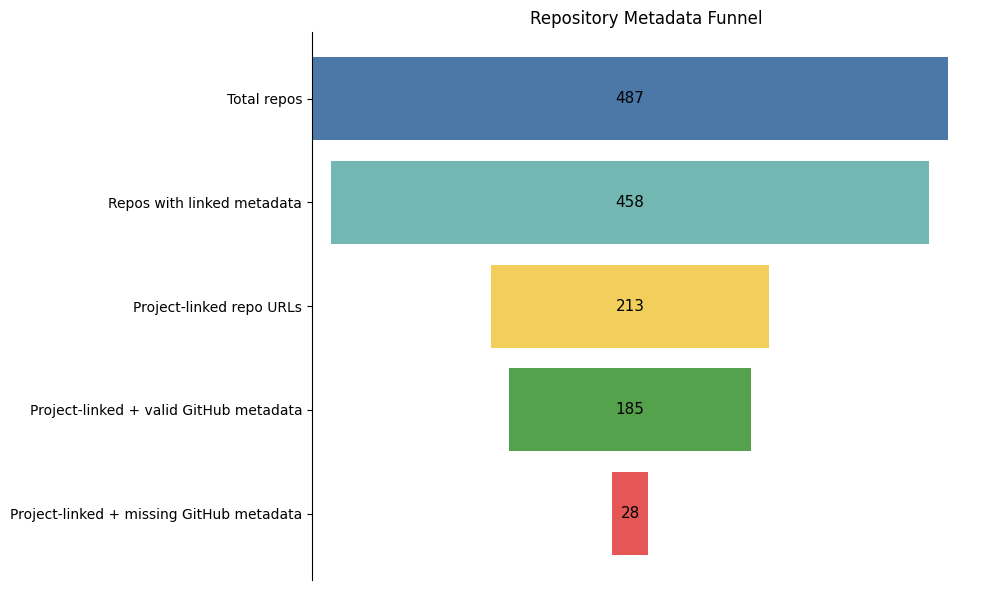

In [111]:
stages = [
    "Total repos",
    "Repos with linked metadata",
    "Project-linked repo URLs",
    "Project-linked + valid GitHub metadata",
    "Project-linked + missing GitHub metadata",
]

values = [
    repo_metadata_df.repo_url.nunique(),
    valid_repo_metadata_mask.sum(),
    linked_project_mask.sum(),
    len(repos_with_project_and_metadata),
    len(repos_with_project_and_no_metadata),
]
max_val = max(values)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = list(range(len(stages)))[::-1]
left_offsets = [(max_val - v) / 2 for v in values]

ax.barh(
    y_pos,
    values,
    left=left_offsets,
    color=["#4C78A8", "#72B7B2", "#F2CF5B", "#54A24B", "#E45756"]
)

ax.set_yticks(y_pos)
ax.set_yticklabels(stages)
ax.set_title("Repository Metadata Funnel")
ax.set_xticks([])

for y, v, left in zip(y_pos, values, left_offsets):
    ax.text(left + v / 2, y, str(v), ha="center", va="center", color="black", fontsize=11)

for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

#### Create derived columns for analysis

In [112]:
repo_metadata_df['true_hackathon_repos'] = False

##### Manually label the true hackathon repositories

In [113]:
eisha_repos = repo_metadata_df[
    repo_metadata_df["owner"].astype("string").str.strip().eq("EishaMazhar")
].copy()

print(f"Repositories owned by EishaMazhar: {len(eisha_repos)}")
# print(eisha_repos.repo_url.tolist())

eisha_true_repos = ["CERN-Webfest-Post-Quantum-Cryptography", "Drive-H-er", "Driveher", "open-pulse-quickstart", "cosmos-sdk", "Safe-pooling-2020", "Safe-Pooling", "Manell"]

sdsc_repos = repo_metadata_df[
    repo_metadata_df["owner"].astype("string").str.strip().eq("sdsc-ordes")
].copy()
sdsc_true_repos = ["open-pulse-quickstart", "ordfts-hackathon-vehicles-detection"]


print(f"Repositories owned by sdsc-ordes: {len(sdsc_repos)}")
# print(sdsc_repos.repo_url.tolist())

hassan_repos = repo_metadata_df[
    repo_metadata_df["owner"].astype("string").str.strip().eq("hassan11196")
].copy()
# print(hassan_repos.repo_url.tolist())
hassan_true_repos = ["amber-ambulance",
                     "amber-ambulance-cloud",
                     "ambulance-app"
                     "argrag",
                     "gemini-alchemy"
                     ]

print(f"Repositories owned by hassan11196: {len(hassan_repos)}")

Repositories owned by EishaMazhar: 69
Repositories owned by sdsc-ordes: 73
Repositories owned by hassan11196: 132


In [114]:

# Mark repos as true hackathon repos when project_foreign_key is present (non-empty)
repo_metadata_df["true_hackathon_repos"] = _non_empty_string_mask(
    repo_metadata_df, "project_foreign_key"
).astype(bool)

# Robust repo-name series (avoids KeyError: 'name')
if "name" in repo_metadata_df.columns:
    repo_name_series = repo_metadata_df["name"].astype("string").str.strip()
elif "repo_name" in repo_metadata_df.columns:
    repo_name_series = repo_metadata_df["repo_name"].astype("string").str.strip()
elif "repo" in repo_metadata_df.columns:
    repo_name_series = repo_metadata_df["repo"].astype("string").str.strip()
else:
    repo_name_series = repo_metadata_df["repo_url"].astype("string").str.rstrip("/").str.split("/").str[-1]

owner_series = (
    repo_metadata_df["owner"].astype("string").str.strip()
    if "owner" in repo_metadata_df.columns
    else repo_metadata_df["name_with_owner"].astype("string").str.split("/").str[0].str.strip()
)

repo_metadata_df["true_hackathon_repos"] = (
    repo_metadata_df["true_hackathon_repos"]
    | (
        owner_series.eq("EishaMazhar")
        & repo_name_series.isin(eisha_true_repos)
    )
    | (
        owner_series.eq("sdsc-ordes")
        & repo_name_series.isin(sdsc_true_repos)
    )
    | (
        owner_series.eq("hassan11196")
        & repo_name_series.isin(hassan_true_repos)
    )
)

repo_metadata_df["true_hackathon_repos"].value_counts(dropna=False)

true_hackathon_repos
False    261
True     226
Name: count, dtype: int64[pyarrow]

In [115]:
project_keys_count_gt1 = (
    repo_metadata_df.loc[linked_project_mask]
    .groupby("project_foreign_key")["repo_url"]
    .nunique()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)

# print(project_keys_count_gt1)
# This can further help identify multi-repo projects and only mark tru repos manually out of mutiple repos linked to the same project (task for later)

## EPFL Concepts Enrichment

Use the EPFL Graph / EPFL Concepts API to assign concepts to each repository from its available text fields.

The defaults are intentionally fast for notebook iteration: `max_repos=10`, `max_chars=4000`, `include_readme=False`, `max_tries=2`, `delay_retry=2`.
Increase them only after the small test run looks correct.

Set credentials before running this cell, either by:
- pointing `EPFL_GRAPH_API_JSON` to a local GraphAI credentials JSON file, or
- exporting `EPFL_GRAPH_API_HOST`, `EPFL_GRAPH_API_PORT`, `EPFL_GRAPH_API_USER`, and `EPFL_GRAPH_API_PASSWORD`.

In [118]:
import tempfile
import time
import logging

log = logging.getLogger(__name__)

DEFAULT_MAX_CHARS = 4000
DEFAULT_MAX_TRIES = 2
DEFAULT_DELAY_RETRY = 2


def _build_graph_api_json_from_env() -> Path | None:
    """Build a temporary credentials JSON from env vars."""
    import os
    
    host = os.getenv("EPFL_GRAPH_API_HOST")
    port = os.getenv("EPFL_GRAPH_API_PORT")
    user = os.getenv("EPFL_GRAPH_API_USER")
    password = os.getenv("EPFL_GRAPH_API_PASSWORD")

    if not all([host, port, user, password]):
        return None

    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False)
    json.dump(
        {
            "host": host.rstrip("/"),
            "port": int(port),
            "user": user,
            "password": password,
        },
        tmp,
    )
    tmp.flush()
    tmp.close()
    return Path(tmp.name)


def _get_login_info() -> dict | None:
    """Attempt to authenticate with EPFL Graph API. Returns None on failure."""
    import os
    
    try:
        from graphai_client.client_api.utils import login
    except ImportError:
        log.info("graphai-client not installed — skipping concept enrichment")
        return None

    # Try env var pointing to JSON file first
    json_path = os.getenv("EPFL_GRAPH_API_JSON")
    if json_path and Path(json_path).exists():
        try:
            return login(json_path)
        except Exception as e:
            log.warning("EPFL Graph API login failed with JSON file: %s", e)
            return None

    # Try building from individual env vars
    tmp_path = _build_graph_api_json_from_env()
    if tmp_path is None:
        log.info("EPFL Graph API credentials not configured — skipping concept enrichment")
        return None

    try:
        return login(str(tmp_path))
    except Exception as e:
        log.warning("EPFL Graph API login failed: %s", e)
        return None
    finally:
        tmp_path.unlink(missing_ok=True)


def _coerce_string_list(value) -> list[str]:
    """Parse a value into a list of strings."""
    if value is None:
        return []
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return []
        try:
            value = json.loads(stripped)
        except (json.JSONDecodeError, ValueError):
            return [stripped]
    if isinstance(value, (list, tuple, set)):
        return [str(item).strip() for item in value if str(item).strip()]
    return [str(value).strip()] if str(value).strip() else []


def build_repo_text(row: dict, max_chars: int = DEFAULT_MAX_CHARS) -> str:
    """Build a text blob from repo metadata for concept extraction."""
    parts = [
        row.get("repo_name") or row.get("repo") or row.get("name_with_owner"),
        row.get("description"),
    ]

    topics = _coerce_string_list(row.get("topics") or row.get("repo_topics"))
    if topics:
        parts.append("Topics: " + ", ".join(topics))

    readme = row.get("readme_text")
    if isinstance(readme, str) and readme.strip():
        parts.append(readme.strip())

    text = "\n\n".join(
        str(p).strip() for p in parts if isinstance(p, str) and p.strip()
    )
    return text[:max_chars]


def extract_concepts_for_repo(row: dict, login_info: dict) -> dict:
    """Extract concepts for a single repo row.
    
    Returns dict with:
    - repo_concepts (list[dict]): raw API response
    - repo_concept_names (list[str])
    - repo_top_concept (str | None)
    - repo_concepts_error (str | None)
    """
    from graphai_client.client_api.text import extract_concepts_from_text

    text = build_repo_text(row)
    if not text.strip():
        return {
            "repo_concepts": [],
            "repo_concept_names": [],
            "repo_top_concept": None,
            "repo_concepts_error": "empty_text",
        }

    try:
        concepts = extract_concepts_from_text(
            text,
            login_info,
            restrict_to_ontology=True,
            max_tries=DEFAULT_MAX_TRIES,
            delay_retry=DEFAULT_DELAY_RETRY,
        ) or []
    except Exception as e:
        log.warning("Concept extraction failed: %s", e)
        return {
            "repo_concepts": [],
            "repo_concept_names": [],
            "repo_top_concept": None,
            "repo_concepts_error": str(e),
        }

    concept_names = [
        c.get("concept_name") for c in concepts
        if isinstance(c, dict) and c.get("concept_name")
    ]

    return {
        "repo_concepts": concepts,
        "repo_concept_names": concept_names,
        "repo_top_concept": concept_names[0] if concept_names else None,
        "repo_concepts_error": None,
    }


def try_enrich_with_concepts(row: dict) -> dict:
    """Attempt to enrich a repo row with EPFL concepts.
    
    Returns a dict with concept fields. If anything fails (no credentials,
    API down, import error), returns default values with empty concepts.
    This function NEVER raises — it always falls back gracefully.
    """
    defaults = {
        "repo_concepts": [],
        "repo_concept_names": [],
        "repo_top_concept": None,
        "repo_concepts_error": "not_attempted",
    }

    try:
        login_info = _get_login_info()
        if login_info is None:
            defaults["repo_concepts_error"] = "no_credentials"
            return defaults

        result = extract_concepts_for_repo(row, login_info)
        log.info("Extracted %d concepts for repo", len(result["repo_concept_names"]))
        return result

    except Exception as e:
        log.warning("Concept enrichment failed: %s", e)
        defaults["repo_concepts_error"] = str(e)
        return defaults


In [124]:
# Full enrichment loop with incremental cache updating
import time

print(f"Starting enrichment loop for {len(repo_metadata_df)} repos...")
print(f"Cache already has {len(concept_cache)} repos, will skip those")

# Initialize enriched data by copying repo_metadata_df
repo_metadata_with_concepts = repo_metadata_df.copy()

# Add concept columns if missing
concept_cols = ["repo_concepts", "repo_concept_names", "repo_top_concept", "repo_concepts_error"]
for col in concept_cols:
    if col not in repo_metadata_with_concepts.columns:
        repo_metadata_with_concepts[col] = None

# Track progress
enriched_count = 0
cached_count = 0
failed_count = 0
failed_urls = []
consecutive_failures = 0
MAX_CONSECUTIVE_FAILURES = 30
start_time = time.time()

# Enrich each repo
for idx, row in repo_metadata_df.iterrows():
    repo_url = row.get("repo_url")
    if not repo_url:
        continue
    
    # Check cache first
    if repo_url in concept_cache and concept_cache[repo_url].get("repo_concepts_error") is None:
        # Use cached data — must use .at for list-valued columns
        for col in concept_cols:
            repo_metadata_with_concepts.at[idx, col] = concept_cache[repo_url].get(col)
        cached_count += 1
    else:
        # Enrich this repo
        try:
            result = try_enrich_with_concepts(row.to_dict())
            
            # Update DataFrame — use .at for list-valued columns
            repo_metadata_with_concepts.at[idx, "repo_concepts"] = result.get("repo_concepts", [])
            repo_metadata_with_concepts.at[idx, "repo_concept_names"] = result.get("repo_concept_names", [])
            repo_metadata_with_concepts.at[idx, "repo_top_concept"] = result.get("repo_top_concept")
            repo_metadata_with_concepts.at[idx, "repo_concepts_error"] = result.get("repo_concepts_error")
            
            # Update cache
            concept_cache[repo_url] = {
                "repo_concepts": result.get("repo_concepts", []),
                "repo_concept_names": result.get("repo_concept_names", []),
                "repo_top_concept": result.get("repo_top_concept"),
                "repo_concepts_error": result.get("repo_concepts_error"),
            }
            
            if result.get("repo_concepts_error"):
                failed_count += 1
                consecutive_failures += 1
                failed_urls.append((repo_url, result["repo_concepts_error"]))
            else:
                enriched_count += 1
                consecutive_failures = 0
            
        except Exception as e:
            repo_metadata_with_concepts.at[idx, "repo_concepts_error"] = str(e)
            failed_count += 1
            consecutive_failures += 1
            failed_urls.append((repo_url, str(e)))
    
    # Checkpoint every 20 newly processed repos
    total_processed = enriched_count + failed_count
    if total_processed > 0 and total_processed % 20 == 0:
        cache_path = DATA_ROOT / "repo_concepts_cache.json"
        with open(cache_path, 'w') as f:
            json.dump(concept_cache, f, indent=2)
        print(f"  Checkpoint: {enriched_count} new, {cached_count} from cache, {failed_count} failed")
        if failed_urls:
            print(f"  Failed URLs so far:")
            for url, err in failed_urls:
                print(f"    {url} — {err}")
    
    # Stop early if API is consistently down
    if consecutive_failures >= MAX_CONSECUTIVE_FAILURES:
        print(f"\n⛔ Stopping: {MAX_CONSECUTIVE_FAILURES} consecutive failures — API appears to be down.")
        break

# Final cache save
cache_path = DATA_ROOT / "repo_concepts_cache.json"
with open(cache_path, 'w') as f:
    json.dump(concept_cache, f, indent=2)

elapsed = time.time() - start_time
print(f"\n✓ Enrichment complete!")
print(f"  New enrichments: {enriched_count} repos ({enriched_count/max(elapsed, 0.001):.1f} repos/sec)")
print(f"  From cache: {cached_count} repos")
print(f"  Failed: {failed_count} repos")
print(f"  Total time: {elapsed:.1f}s")
print(f"  Cache saved to: {cache_path}")

if failed_urls:
    print(f"\n⚠️  Failed repos ({len(failed_urls)}):")
    for url, err in failed_urls:
        print(f"    {url} — {err}")


Starting enrichment loop for 487 repos...
Cache already has 178 repos, will skip those


Concept extraction failed: HTTPConnectionPool(host='127.0.0.1', port=5555): Max retries exceeded with url: /api/tasks (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x162574160>: Failed to establish a new connection: [Errno 61] Connection refused'))


[2026-04-26 11:59:14] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True


Concept extraction failed: HTTPConnectionPool(host='127.0.0.1', port=5555): Max retries exceeded with url: /api/tasks (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x1560bfac0>: Failed to establish a new connection: [Errno 61] Connection refused'))


[2026-04-26 11:59:15] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True


...

[2026-04-26 14:22:40] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True


Concept extraction failed: HTTPConnectionPool(host='127.0.0.1', port=5555): Max retries exceeded with url: /api/tasks (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x1560bff00>: Failed to establish a new connection: [Errno 61] Connection refused'))


[2026-04-26 14:25:01] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True


Concept extraction failed: HTTPConnectionPool(host='127.0.0.1', port=5555): Max retries exceeded with url: /api/tasks (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x1560bf9b0>: Failed to establish a new connection: [Errno 61] Connection refused'))


[2026-04-26 14:25:02] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True

✓ Enrichment complete!
  New enrichments: 290 repos (0.0 repos/sec)
  From cache: 154 repos
  Failed: 43 repos
  Total time: 8796.3s
  Cache saved to: /Users/eisha/Documents/hackathon_analysis/data/repo_concepts_cache.json

⚠️  Failed repos (43):
    https://github.com/Corentin00/sf — HTTPConnectionPool(host='127.0.0.1', port=5555): Max retries exceeded with url: /api/tasks (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x162574160>: Failed to establish a new connection: [Errno 61] Connection refused'))
    https://github.com/EduardoNeville/CapitalNetworksAi — HTTPConnectionPool(host='127.0.0.1', port=5555

In [125]:
out_csv = DATA_ROOT / "repo_metadata_with_concepts.csv"
out_parquet = DATA_ROOT / "repo_metadata_with_concepts.parquet"
cache_path = DATA_ROOT / "repo_concepts_cache.json"

# Export to CSV and Parquet
repo_metadata_with_concepts.to_csv(out_csv, index=False)
repo_metadata_with_concepts.to_parquet(out_parquet, index=False)
print(f"Exported to:\n  {out_csv}\n  {out_parquet}")

# Update and save cache from concept columns (ensures consistency with DataFrame)
concept_cols = ["repo_concepts", "repo_concept_names", "repo_top_concept", "repo_concepts_error"]
for _, row in repo_metadata_with_concepts.iterrows():
    repo_url = row["repo_url"]
    concept_cache[repo_url] = {
        "repo_concepts": row.get("repo_concepts", []),
        "repo_concept_names": row.get("repo_concept_names", []),
        "repo_top_concept": row.get("repo_top_concept"),
        "repo_concepts_error": row.get("repo_concepts_error"),
    }

with open(cache_path, 'w') as f:
    json.dump(concept_cache, f, indent=2)
print(f"\nConcept cache saved with {len(concept_cache)} repos to:\n  {cache_path}")

# Now upload everything to Hugging Face Hub
print("\n📤 Uploading to Hugging Face Hub...")
try:
    from hackathon_analysis.common_utils import upload_to_hugging_face
    upload_to_hugging_face(DATA_ROOT, path_in_repo="data/", verbose=False)
    print("✓ Uploaded to Hugging Face Hub (data/)")
except Exception as e:
    print(f"⚠️  Upload failed: {e}")

Exported to:
  /Users/eisha/Documents/hackathon_analysis/data/repo_metadata_with_concepts.csv
  /Users/eisha/Documents/hackathon_analysis/data/repo_metadata_with_concepts.parquet

Concept cache saved with 487 repos to:
  /Users/eisha/Documents/hackathon_analysis/data/repo_concepts_cache.json

📤 Uploading to Hugging Face Hub...


Processing Files (20 / 20): 100%|██████████| 47.8MB / 47.8MB, 12.6MB/s  
New Data Upload: 100%|██████████| 44.9MB / 44.9MB, 11.8MB/s  


✓ Uploaded to Hugging Face Hub (data/)


In [126]:
repo_metadata_with_concepts.info()

<class 'pandas.DataFrame'>
RangeIndex: 487 entries, 0 to 486
Data columns (total 70 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   repo_url                          487 non-null    string             
 1   commit_count_default_branch       487 non-null    int64              
 2   contributors_count                487 non-null    int64              
 3   contributors_top                  458 non-null    object             
 4   created_at                        458 non-null    datetime64[us, UTC]
 5   default_branch                    487 non-null    string             
 6   description                       487 non-null    string             
 7   dirs_total_count                  487 non-null    int64              
 8   files_root_entries                458 non-null    object             
 9   files_total_count                 487 non-null    int64              
 10  f

In [127]:
# Load enriched data: in-memory > parquet > rebuild from JSON cache
parquet_path = DATA_ROOT / "repo_metadata_with_concepts.parquet"
cache_path = DATA_ROOT / "repo_concepts_cache.json"

if "repo_metadata_with_concepts" in globals() and repo_metadata_with_concepts is not None:
    repo_metadata_df = repo_metadata_with_concepts.copy()
    print("Loaded repo_metadata_df from in-memory enrichment result.")

elif parquet_path.exists():
    repo_metadata_df = pd.read_parquet(parquet_path).convert_dtypes()

    # Deserialize JSON-encoded list/dict columns back to Python objects
    json_list_cols = ["repo_concepts", "repo_concept_names"]
    for col in json_list_cols:
        if col in repo_metadata_df.columns:
            repo_metadata_df[col] = repo_metadata_df[col].apply(
                lambda v: json.loads(v) if isinstance(v, str) and v.strip() else (v if isinstance(v, list) else [])
            )

    # Restore date columns
    date_cols = [
        "created_at", "updated_at", "pushed_at",
        "first_commit_date_default_branch", "last_commit_date_default_branch",
        "latest_release_date",
    ]
    for col in date_cols:
        if col in repo_metadata_df.columns:
            repo_metadata_df[col] = pd.to_datetime(repo_metadata_df[col], errors="coerce")

    # Restore boolean columns
    bool_cols = repo_metadata_df.select_dtypes(include=["boolean"]).columns.tolist()
    if bool_cols:
        repo_metadata_df[bool_cols] = repo_metadata_df[bool_cols].fillna(False).astype("boolean")

    # Rebuild derived feature columns to stay in sync with pre-enrichment state
    repo_metadata_df = build_repo_analysis_features(repo_metadata_df)

    # Restore true_hackathon_repos as bool
    if "true_hackathon_repos" in repo_metadata_df.columns:
        repo_metadata_df["true_hackathon_repos"] = repo_metadata_df["true_hackathon_repos"].fillna(False).astype(bool)

    print(f"Loaded repo_metadata_df from parquet: {parquet_path}")

elif cache_path.exists():
    # Rebuild from JSON cache + current repo_metadata_df
    print(f"No parquet found, rebuilding from JSON cache: {cache_path}")
    cache = load_concept_cache(cache_path)
    print(f"  Cache has {len(cache)} repos")

    concept_rows = []
    for repo_url in repo_metadata_df["repo_url"]:
        if repo_url in cache:
            entry = cache[repo_url]
            concept_rows.append({
                "repo_url": repo_url,
                "repo_concepts": entry.get("repo_concepts", []),
                "repo_concept_names": entry.get("repo_concept_names", []),
                "repo_top_concept": entry.get("repo_top_concept"),
                "repo_concepts_error": None,
            })
        else:
            concept_rows.append({
                "repo_url": repo_url,
                "repo_concepts": [],
                "repo_concept_names": [],
                "repo_top_concept": None,
                "repo_concepts_error": None,
            })

    concept_df = pd.DataFrame(concept_rows)
    drop_cols = ["repo_concepts", "repo_concept_names", "repo_top_concept", "repo_concepts_error"]
    repo_metadata_df = repo_metadata_df.drop(columns=[c for c in drop_cols if c in repo_metadata_df.columns], errors="ignore")
    repo_metadata_df = repo_metadata_df.merge(concept_df, on="repo_url", how="left")

    # Warn about repos that have valid metadata but are missing from cache
    if "has_valid_metadata" in repo_metadata_df.columns:
        valid_meta_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
        has_concepts_mask = repo_metadata_df["repo_concept_names"].map(
            lambda v: isinstance(v, list) and len(v) > 0
        )
        missing_concepts = (valid_meta_mask & ~has_concepts_mask).sum()
        if missing_concepts > 0:
            print(f"\n  WARNING: {missing_concepts} repos have valid metadata but no concepts in cache.")
            print(f"  Re-run the enrichment cell (Cell 20) to fetch the missing repos incrementally.")

    print(f"  Rebuilt repo_metadata_df with concept columns from cache.")

else:
    raise FileNotFoundError(
        f"No enriched data found. Run the EPFL enrichment cell first.\n"
        f"  Expected parquet: {parquet_path}\n"
        f"  Expected cache: {cache_path}"
    )

print(f"Shape: {repo_metadata_df.shape}")
repo_metadata_df.head(10)

Loaded repo_metadata_df from in-memory enrichment result.
Shape: (487, 70)


,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,active_days_default_branch,commit_log,stars_log,contributors_count_log,contributors_total,true_hackathon_repos,repo_concepts,repo_concept_names,repo_top_concept,repo_concepts_error
0,https://github.com/22cav/lauzhack2025,21,4,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22 13:18:04+00:00,lauzhack2025,Control Blender in real-time with hand gestures,19,"[{'path': '.gitignore', 'size': 485, 'type': '...",76,...,1.0,3.091042,1.609438,1.609438,8,True,"[{'concept_id': 1400452, 'concept_name': 'Gest...","[Gesture recognition, Blender (software), Gest...",Gesture recognition,None
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41,4,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30 13:21:59+00:00,main,Our project for the Vitol challenge at LauzHac...,1,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13,...,1.0,3.737670,1.098612,1.609438,8,True,"[{'concept_id': 544592, 'concept_name': 'Requi...","[Requirement, Requirements analysis, Business ...",Requirement,None
2,https://github.com/ALIANTE-IoT/ALIANTE,29,5,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22 11:25:55+00:00,main,A distributed system for automated biodiversit...,24,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73,...,0.0,3.401197,0.000000,1.791759,10,True,"[{'concept_id': 669675, 'concept_name': 'Clust...","[Cluster analysis, Image segmentation, Cloud s...",Cluster analysis,None
3,https://github.com/AaronDinesh/lauzhack-2025,109,4,"[{'contributions': 49, 'html_url': 'https://gi...",2025-11-22 10:46:30+00:00,main,,19,"[{'path': '.gitignore', 'size': 5201, 'type': ...",66,...,1.0,4.700480,1.098612,1.609438,8,True,[],[],None,None
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,9,2,"[{'contributions': 8, 'html_url': 'https://git...",2025-11-22 20:56:29+00:00,main,,17,"[{'path': '.gitignore', 'size': 953, 'type': '...",123,...,0.0,2.302585,0.693147,1.098612,4,True,"[{'concept_id': 219072, 'concept_name': 'Risk ...","[Risk assessment, Customer satisfaction, Data ...",Risk assessment,None
5,https://github.com/Aleksandar204/Lauzhack2025-SBB,40,4,"[{'contributions': 25, 'html_url': 'https://gi...",2025-11-22 17:33:39+00:00,master,,39,"[{'path': '.gitignore', 'size': 17, 'type': 'f...",70,...,88.0,3.713572,0.000000,1.609438,8,True,"[{'concept_id': 2261519, 'concept_name': 'User...","[User interface design, User interface, Androi...",User interface design,None
6,https://github.com/AliEmreSenel/LauzHack2023,11,2,"[{'contributions': 7, 'html_url': 'https://git...",2023-12-02 13:48:20+00:00,master,,127,"[{'path': '.gitattributes', 'size': 55, 'type'...",544,...,0.0,2.484907,0.693147,1.098612,4,True,"[{'concept_id': 45249, 'concept_name': 'User i...","[User interface, Graphical user interface, Use...",User interface,None
7,https://github.com/AmirMFarhang/LauzHack-Cassa...,12,3,"[{'contributions': 6, 'html_url': 'https://git...",2024-11-30 17:43:22+00:00,main,A platform for forcasting information based on...,0,"[{'path': '.gitignore', 'size': 3169, 'type': ...",8,...,5.0,2.564949,0.000000,1.386294,6,True,"[{'concept_id': 8837930, 'concept_name': 'Mark...","[Market analysis, Market research, Target market]",Market analysis,None
8,https://github.com/AndreaIannoli/JuicyBank,9,2,"[{'contributions': 6, 'html_url': 'https://git...",2024-11-30 13:06:30+00:00,main,The repo for the UBS LauzHack's challenge,1,"[{'path': '.gitignore', 'size': 3139, 'type': ...",6,...,0.0,2.302585,0.000000,1.098612,4,True,"[{'concept_id': 289702, 'concept_name': 'DARPA...","[DARPA Grand Challenge, Kaggle, Challenge–resp...",DARPA Grand Challenge,None
9,https://github.com/Barlassen/AZKT-System-,9,3,"[{'contributions': 5, 'html_url': 'https://git...",2025-11-22 12:59:07+00:00,main,Anonymouse Zero Knowledge Ticket System For SB...,19,"[{'path': '.gitignore', 'size': 462, 'type': '...",90,...,0.0

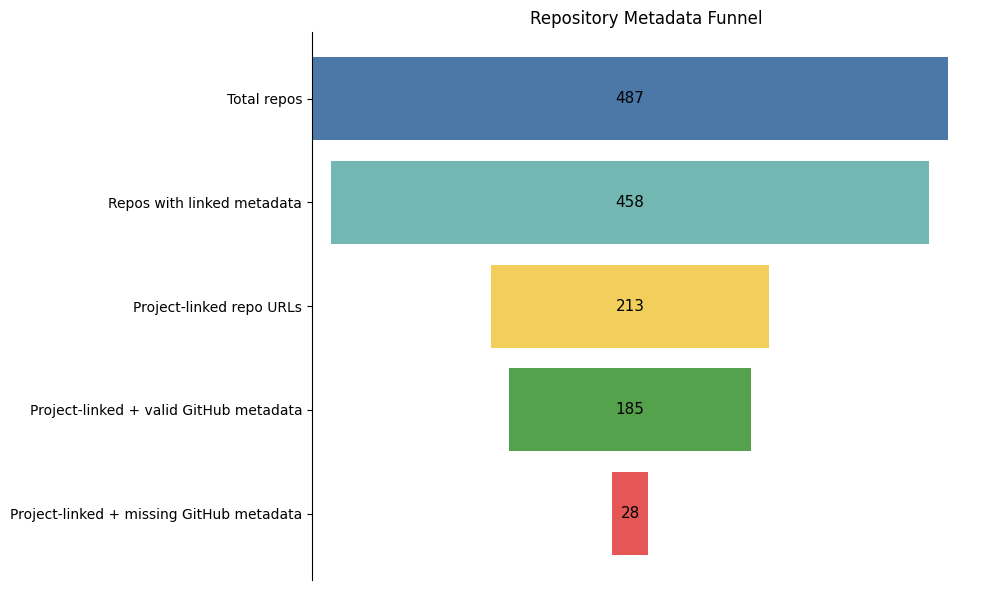

In [128]:
stages = [
    "Total repos",
    "Repos with linked metadata",
    "Project-linked repo URLs",
    "Project-linked + valid GitHub metadata",
    "Project-linked + missing GitHub metadata",
]

values = [
    repo_metadata_df.repo_url.nunique(),
    valid_repo_metadata_mask.sum(),
    linked_project_mask.sum(),
    len(repos_with_project_and_metadata),
    len(repos_with_project_and_no_metadata),
]
max_val = max(values)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = list(range(len(stages)))[::-1]
left_offsets = [(max_val - v) / 2 for v in values]

ax.barh(
    y_pos,
    values,
    left=left_offsets,
    color=["#4C78A8", "#72B7B2", "#F2CF5B", "#54A24B", "#E45756"]
)

ax.set_yticks(y_pos)
ax.set_yticklabels(stages)
ax.set_title("Repository Metadata Funnel")
ax.set_xticks([])

for y, v, left in zip(y_pos, values, left_offsets):
    ax.text(left + v / 2, y, str(v), ha="center", va="center", color="black", fontsize=11)

for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Counts:


,count
true_hackathon_repos,
False,261
True,226


<Axes: title={'center': 'True Hackathon Repos Distribution'}>

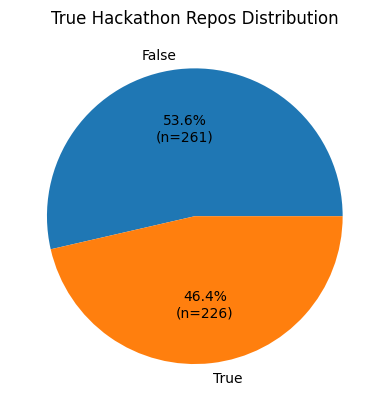

In [129]:
counts = repo_metadata_df["true_hackathon_repos"].value_counts(dropna=False)
total = counts.sum()

print("Counts:")
display(counts.rename("count").to_frame())

counts.plot(
    kind="pie",
    title="True Hackathon Repos Distribution",
    ylabel="",
    autopct=lambda p: f"{p:.1f}%\n(n={int(round(p * total / 100.0))})",
)

True hackathon repos with metadata: 198 / 226


<Axes: title={'center': 'True Hackathon Repos: Metadata Coverage'}>

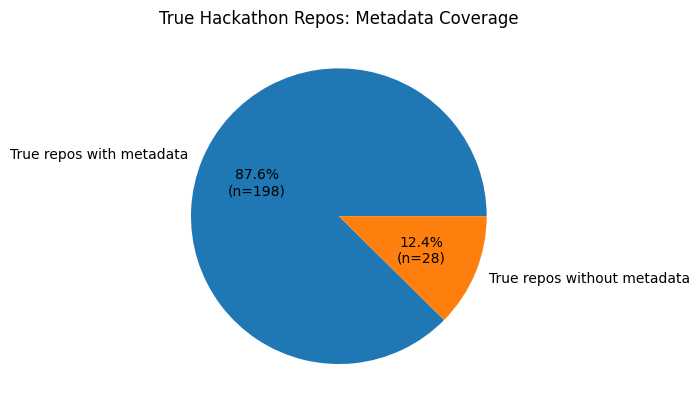

In [130]:
# Pie 2: inside true hackathon repos (with metadata vs without metadata)
true_mask = repo_metadata_df["true_hackathon_repos"].fillna(False).astype(bool)

if "has_valid_metadata" in repo_metadata_df.columns:
    valid_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
else:
    valid_mask = valid_repo_metadata_mask.fillna(False).astype(bool)

true_with_meta = (true_mask & valid_mask).sum()
true_without_meta = (true_mask & ~valid_mask).sum()

true_meta_counts = pd.Series(
    {
        "True repos with metadata": int(true_with_meta),
        "True repos without metadata": int(true_without_meta),
    }
)
true_meta_total = int(true_meta_counts.sum())

print(f"True hackathon repos with metadata: {int(true_with_meta)} / {int(true_meta_total)}")

true_meta_counts.plot(
    kind="pie",
    ylabel="",
    title="True Hackathon Repos: Metadata Coverage",
    autopct=lambda p: f"{p:.1f}%\n(n={int(round(p * true_meta_total / 100.0))})",
)

true_hackathon_repos,False repos,True repos
has_ci,36.2,3.5
has_contributing,18.5,1.0
has_docker,18.1,8.6
has_docs,21.5,5.6
has_license_file,52.3,17.2
has_notebooks,11.9,17.7
has_readme_file,92.3,88.9
has_tests,16.9,4.0


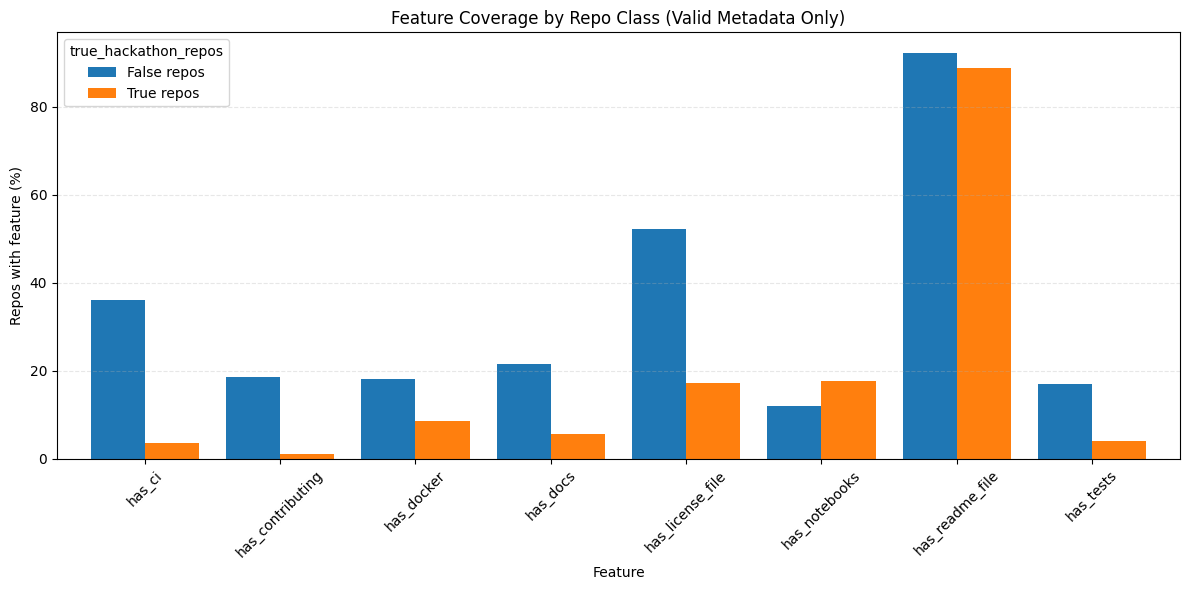

In [131]:
# Compare feature coverage (%) between true vs false hackathon repos
source_df = valid_repo_df.copy() if "valid_repo_df" in globals() else repo_metadata_df[repo_metadata_df["has_valid_metadata"]].copy()

feature_cols = [
    "has_docs",
    "has_readme_file",
    "has_tests",
    "has_license_file",
    "has_ci",
    "has_contributing",
    "has_docker",
    "has_notebooks",
]
feature_cols = [c for c in feature_cols if c in source_df.columns]

plot_df = source_df.copy()
plot_df["true_hackathon_repos"] = plot_df["true_hackathon_repos"].fillna(False).astype(bool)

for col in feature_cols:
    plot_df[col] = plot_df[col].fillna(False).astype(bool)

feature_pct = (
    plot_df.groupby("true_hackathon_repos")[feature_cols]
    .mean()
    .mul(100)
    .rename(index={False: "False repos", True: "True repos"})
    .T
    .sort_index()
)

ax = feature_pct.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Feature Coverage by Repo Class (Valid Metadata Only)")
ax.set_xlabel("Feature")
ax.set_ylabel("Repos with feature (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="true_hackathon_repos")
ax.grid(axis="y", linestyle="--", alpha=0.3)

display(feature_pct.round(1))
ax.get_figure().tight_layout()

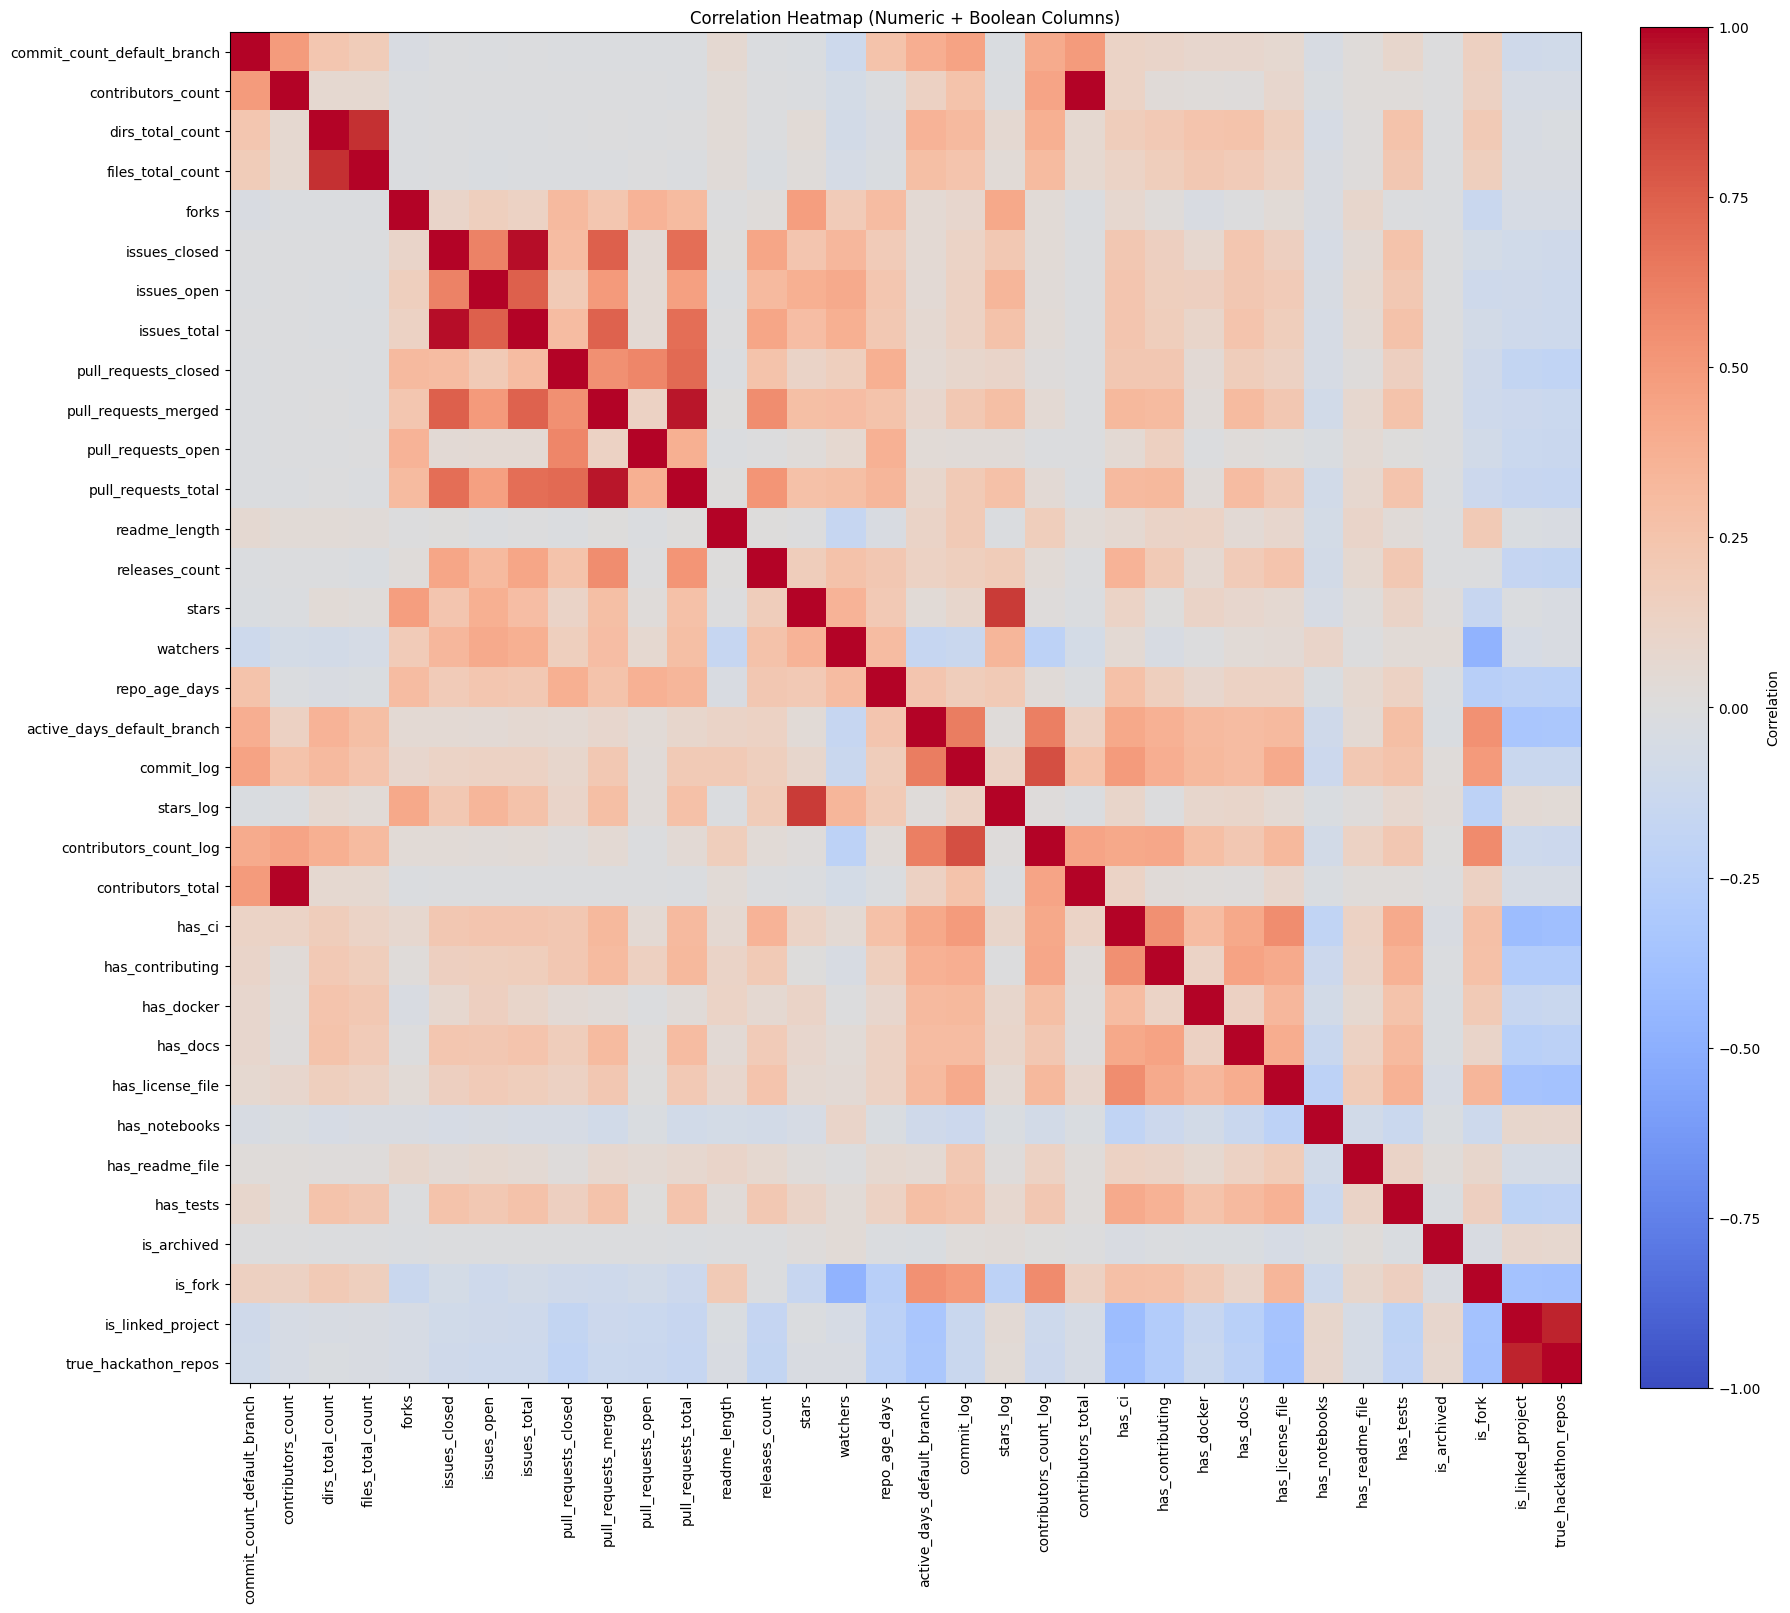

In [132]:
# Use source_df if available, otherwise fall back to repo_metadata_df
corr_source = source_df.copy() if "source_df" in globals() else repo_metadata_df.copy()

bool_cols = corr_source.select_dtypes(include=["bool", "boolean"]).columns.tolist()
numeric_cols = corr_source.select_dtypes(include=["number"]).columns.tolist()

corr_data = corr_source[numeric_cols + bool_cols].copy()

for col in bool_cols:
    corr_data[col] = corr_data[col].astype(int)

# Drop constant columns (no variance) to avoid NaN correlations
corr_data = corr_data.loc[:, corr_data.nunique(dropna=False) > 1]

corr_matrix = corr_data.corr(method="pearson", numeric_only=True)

if corr_matrix.empty:
    raise ValueError("No columns available to plot after filtering numeric/boolean and constant columns.")

# Plot heatmap
fig_size = max(8, min(18, int(len(corr_matrix.columns) * 0.6)))
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap (Numeric + Boolean Columns)")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

/var/folders/b1/02zlb8yx3m5_j30bfvwsxdr40000gn/T/ipykernel_33437/2525681143.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


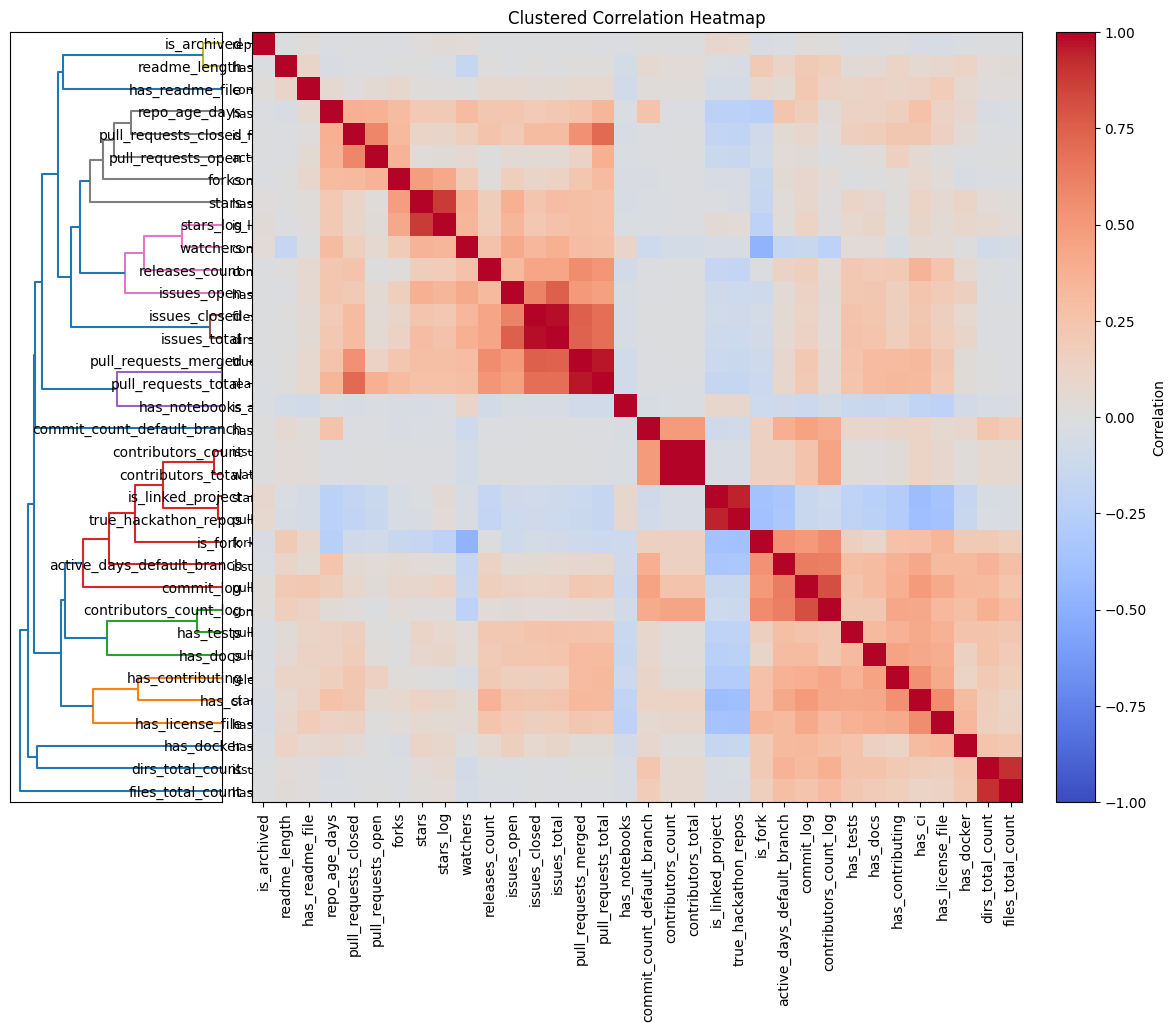

In [133]:


from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

# Start from the same correlation-ready data
cluster_source = source_df.copy() if "source_df" in globals() else repo_metadata_df.copy()

bool_cols = cluster_source.select_dtypes(include=["bool", "boolean"]).columns.tolist()
numeric_cols = cluster_source.select_dtypes(include=["number"]).columns.tolist()

cluster_data = cluster_source[numeric_cols + bool_cols].copy()

for col in bool_cols:
    cluster_data[col] = cluster_data[col].astype(int)

# Drop constant columns
cluster_data = cluster_data.loc[:, cluster_data.nunique(dropna=False) > 1]

corr_matrix = cluster_data.corr(method="pearson", numeric_only=True)

if corr_matrix.empty:
    raise ValueError("No columns available to cluster after filtering.")

# Convert correlation to distance
distance_matrix = 1 - corr_matrix.abs()

# linkage expects condensed distance form
condensed_dist = squareform(distance_matrix.values, checks=False)
linkage_matrix = linkage(condensed_dist, method="average")

# Order columns by clustering
ordered_idx = leaves_list(linkage_matrix)
ordered_cols = corr_matrix.columns[ordered_idx]
ordered_corr = corr_matrix.loc[ordered_cols, ordered_cols]

# Figure layout: dendrogram on left, heatmap on right
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 4], wspace=0.05)

ax_dendro = fig.add_subplot(gs[0, 0])
dendrogram(
    linkage_matrix,
    orientation="left",
    labels=ordered_cols.tolist(),
    ax=ax_dendro,
    color_threshold=None,
)
ax_dendro.set_xticks([])
ax_dendro.tick_params(axis="y", labelsize=9)

ax_heat = fig.add_subplot(gs[0, 1])
im = ax_heat.imshow(ordered_corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_heat.set_xticks(range(len(ordered_cols)))
ax_heat.set_yticks(range(len(ordered_cols)))
ax_heat.set_xticklabels(ordered_cols, rotation=90)
ax_heat.set_yticklabels(ordered_cols)
ax_heat.set_title("Clustered Correlation Heatmap")

cbar = plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

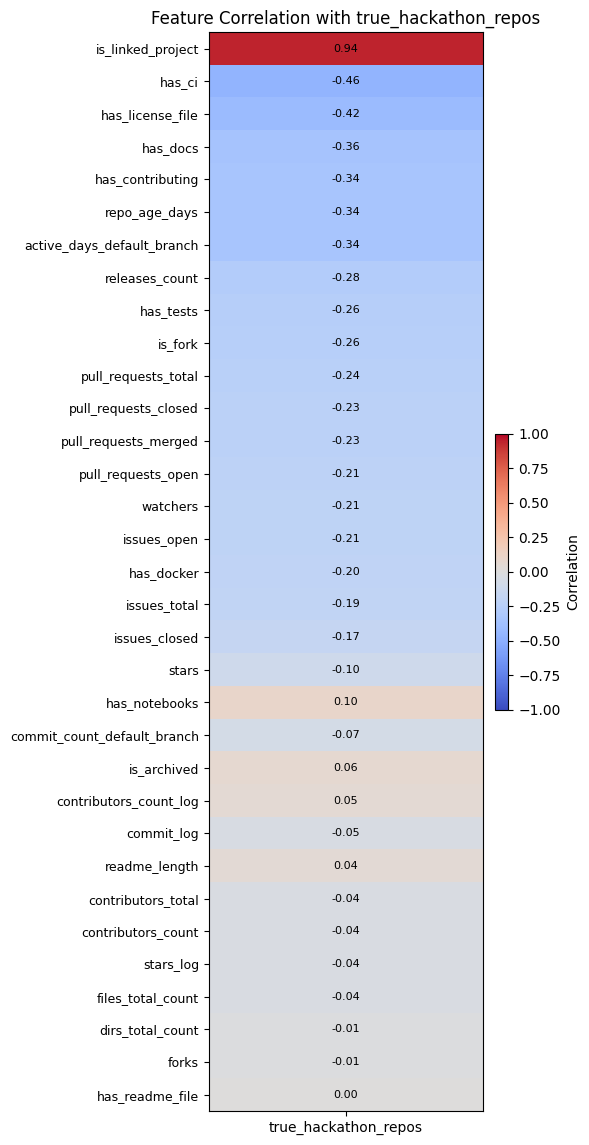

In [ ]:
target_col = "true_hackathon_repos"
target_source = source_df.copy() if "source_df" in globals() else repo_metadata_df.copy()

bool_cols = target_source.select_dtypes(include=["bool", "boolean"]).columns.tolist()
numeric_cols = target_source.select_dtypes(include=["number"]).columns.tolist()

target_data = target_source[numeric_cols + bool_cols].copy()

for col in bool_cols:
    target_data[col] = target_data[col].astype(int)

target_data = target_data.loc[:, target_data.nunique(dropna=False) > 1]

if target_col not in target_data.columns:
    raise ValueError(f"{target_col} is not available for correlation plotting.")

target_corr = (
    target_data.corr(method="pearson", numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

if target_corr.empty:
    raise ValueError("No usable feature correlations found for the target.")

plot_matrix = target_corr.to_frame(name="Correlation with true_hackathon_repos")

fig_h = max(6, len(plot_matrix) * 0.35)
fig, ax = plt.subplots(figsize=(6, fig_h))

im = ax.imshow(plot_matrix.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks([0])
ax.set_xticklabels(["true_hackathon_repos"])
ax.set_yticks(range(len(plot_matrix.index)))
ax.set_yticklabels(plot_matrix.index, fontsize=9)
ax.set_title("Feature Correlation with true_hackathon_repos")

for i, value in enumerate(plot_matrix["Correlation with true_hackathon_repos"]):
    ax.text(
        0,
        i,
        f"{value:.2f}",
        ha="center",
        va="center",
        color="black",
        fontsize=8,
    )

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

Dendogram based heatmap

In [134]:
target = "true_hackathon_repos"

corr_df = repo_metadata_df.copy()
bool_cols = corr_df.select_dtypes(include=["bool", "boolean"]).columns
corr_df[bool_cols] = corr_df[bool_cols].astype(int)

numeric_cols = corr_df.select_dtypes(include=["number"]).columns
target_corr = (
    corr_df[numeric_cols]
    .corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

target_corr.head(20)


is_linked_project             0.947503
has_ci                        0.404905
has_license_file              0.387758
is_fork                       0.381242
active_days_default_branch    0.325699
has_contributing              0.287629
has_error                     0.253017
has_valid_metadata            0.253017
has_docs                      0.240173
repo_age_days                 0.230661
commit_log                    0.220196
has_tests                     0.215070
has_readme_file               0.198947
pull_requests_closed          0.196299
contributors_count_log        0.182456
releases_count                0.179316
pull_requests_total           0.173614
has_docker                    0.154777
pull_requests_open            0.144430
pull_requests_merged          0.140693
Name: true_hackathon_repos, dtype: float64

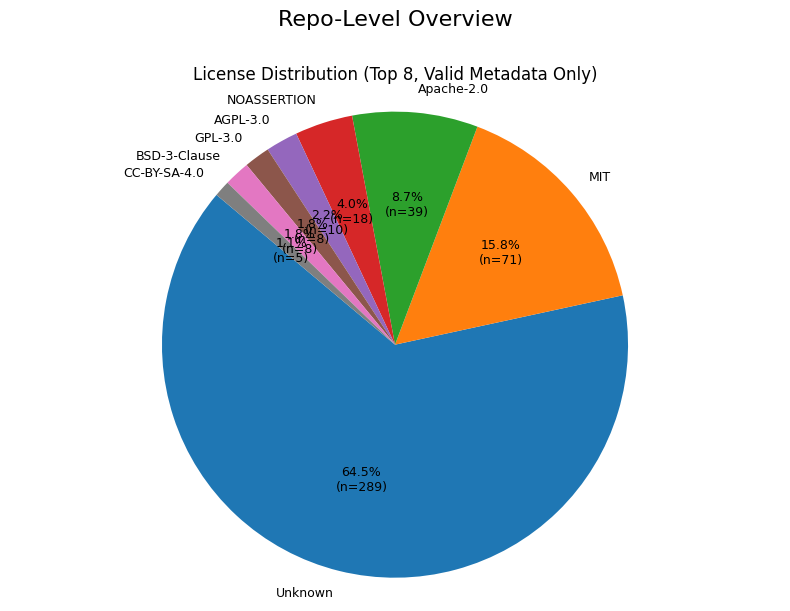

In [135]:
# 6. License distribution (top 8)
# Use available SPDX column (fallback to `license_spdx`) to avoid KeyError
license_col = (
    "repo_license_spdx" if "repo_license_spdx" in repo_metadata_df.columns
    else "license_spdx" if "license_spdx" in repo_metadata_df.columns
    else None
)

if license_col is None:
    license_counts = pd.Series({"Unknown": len(repo_metadata_df)})
else:
    license_counts = (
        repo_metadata_df[license_col]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .fillna("Unknown")
        .value_counts()
        .head(8)
    )

fig, ax = plt.subplots(figsize=(8, 6))

# Recompute license distribution using only repos with valid metadata
if "has_valid_metadata" in repo_metadata_df.columns:
    metadata_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
elif "valid_repo_metadata_mask" in globals():
    metadata_mask = valid_repo_metadata_mask.fillna(False).astype(bool)
else:
    metadata_mask = repo_metadata_df["url"].fillna("").ne("") & repo_metadata_df["error"].fillna("").eq("")

metadata_df = repo_metadata_df.loc[metadata_mask].copy()

if license_col is None:
    license_counts = pd.Series({"Unknown": len(metadata_df)})
else:
    license_counts = (
        metadata_df[license_col]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .fillna("Unknown")
        .value_counts()
        .head(8)
    )

total_licenses = int(license_counts.sum())

def _autopct_with_counts(pct):
    count = int(round((pct / 100.0) * total_licenses))
    return f"{pct:.1f}%\n(n={count})"

ax.pie(
    license_counts.values,
    labels=license_counts.index,
    autopct=_autopct_with_counts,
    startangle=140,
    textprops={"fontsize": 9},
)
ax.set_title("License Distribution (Top 8, Valid Metadata Only)")
ax.axis("equal")

plt.suptitle('Repo-Level Overview', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

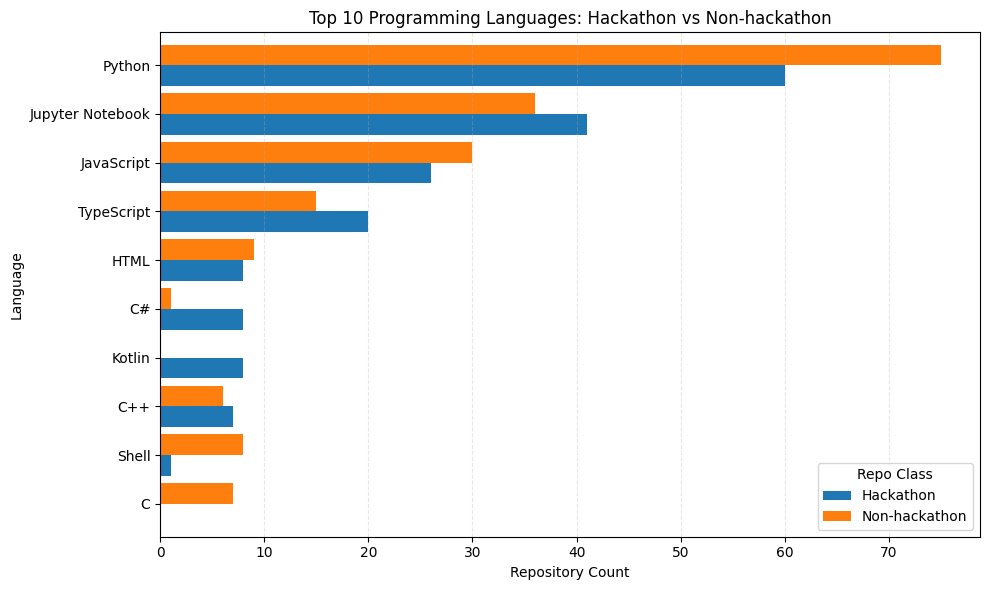

In [136]:
# Top 10 programming languages: hackathon vs non-hackathon
lang_source = (
    source_df.copy()
    if "source_df" in globals()
    else valid_repo_df.copy()
    if "valid_repo_df" in globals()
    else repo_metadata_df.copy()
)

required_cols = ["primary_language", "true_hackathon_repos"]
missing = [c for c in required_cols if c not in lang_source.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

tmp = lang_source.copy()
tmp["primary_language"] = (
    tmp["primary_language"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)
tmp["repo_class"] = tmp["true_hackathon_repos"].fillna(False).astype(bool).map(
    {True: "Hackathon", False: "Non-hackathon"}
)

lang_counts = (
    tmp.dropna(subset=["primary_language"])
    .groupby(["primary_language", "repo_class"])
    .size()
    .unstack(fill_value=0)
)

top10_langs = lang_counts.sum(axis=1).sort_values(ascending=False).head(10).index
plot_df = lang_counts.loc[top10_langs].sort_values(by=lang_counts.columns.tolist(), ascending=True)

ax = plot_df.plot(kind="barh", figsize=(10, 6), width=0.85)
ax.set_title("Top 10 Programming Languages: Hackathon vs Non-hackathon")
ax.set_xlabel("Repository Count")
ax.set_ylabel("Language")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(title="Repo Class")

plt.tight_layout()
plt.show()

propotion basesd for this kind of visulas

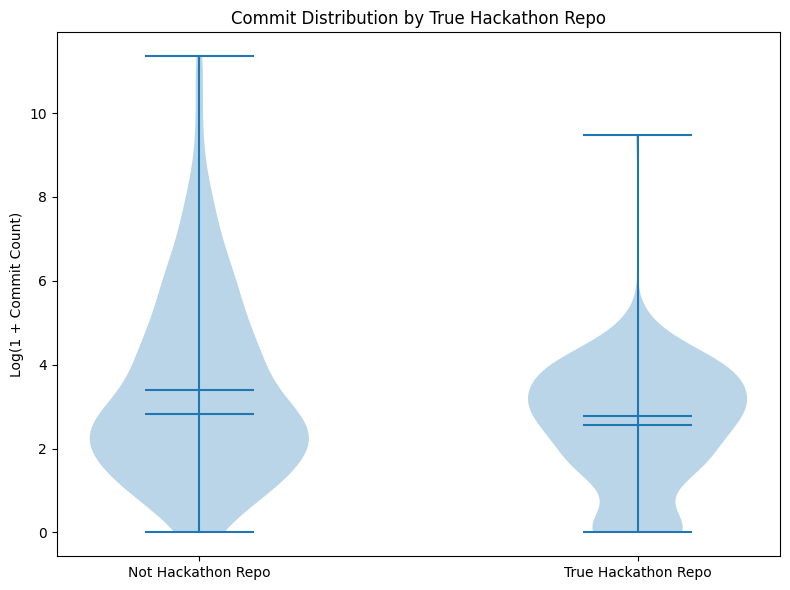

In [137]:
plot_df = repo_metadata_df.copy()

group0 = plot_df.loc[plot_df["true_hackathon_repos"] == 0, "commit_log"].dropna()
group1 = plot_df.loc[plot_df["true_hackathon_repos"] == 1, "commit_log"].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot([group0, group1], showmeans=True, showmedians=True)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Not Hackathon Repo", "True Hackathon Repo"])
ax.set_ylabel("Log(1 + Commit Count)")
ax.set_title("Commit Distribution by True Hackathon Repo")

plt.tight_layout()
plt.show()

Interpretation:
- if the hackathon violin is concentrated low on the y-axis, most hackathon repos have relatively few commits
- if it is taller and more spread out, hackathon repos vary a lot in activity
- if the non-hackathon violin extends much higher, those repos tend to include more heavily developed projects
- if one group has a much higher median, that group is typically more active
- because it’s log-scaled, differences are compressed, so very large commit counts don’t dominate the chart

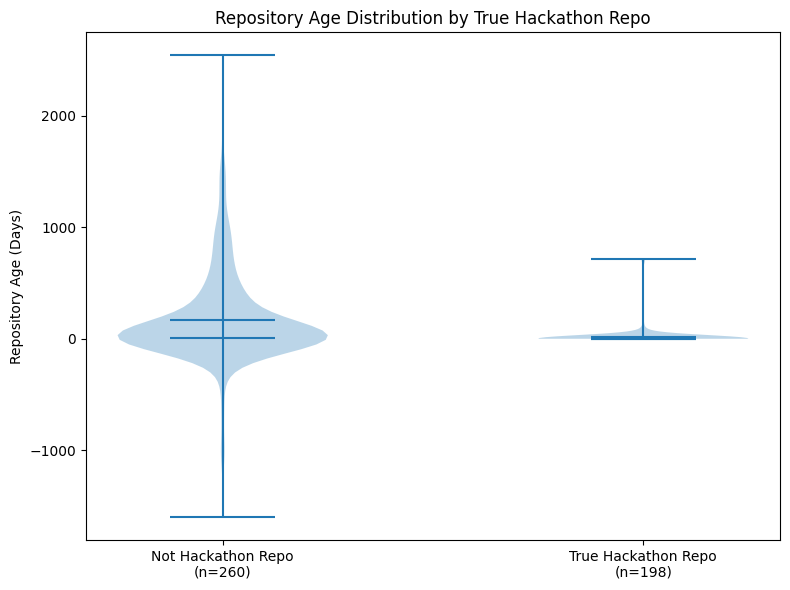

In [138]:
plot_df = repo_metadata_df.copy()

group0 = plot_df.loc[plot_df["true_hackathon_repos"] == 0, "repo_age_days"].dropna()
group1 = plot_df.loc[plot_df["true_hackathon_repos"] == 1, "repo_age_days"].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.violinplot([group0, group1], showmeans=True, showmedians=True)

ax.set_xticks([1, 2])
ax.set_xticklabels([
    f"Not Hackathon Repo\n(n={len(group0)})",
    f"True Hackathon Repo\n(n={len(group1)})"
])
ax.set_ylabel("Repository Age (Days)")
ax.set_title("Repository Age Distribution by True Hackathon Repo")

plt.tight_layout()
plt.show()

##### Now analyse the concepts

In [139]:
import ast

top_n = 10
concept_source = repo_metadata_df.copy()

required_cols = ["true_hackathon_repos"]
missing = [c for c in required_cols if c not in concept_source.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

if "repo_concept_names" not in concept_source.columns and "repo_top_concept" not in concept_source.columns:
    raise KeyError("Need either 'repo_concept_names' or 'repo_top_concept' in repo_metadata_df.")

def _to_list(v):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return []
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    if isinstance(v, str):
        s = v.strip()
        if not s:
            return []
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
            if isinstance(parsed, str) and parsed.strip():
                return [parsed.strip()]
        except Exception:
            pass
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
            if isinstance(parsed, str) and parsed.strip():
                return [parsed.strip()]
        except Exception:
            pass
        return [s]
    return [str(v).strip()] if str(v).strip() else []

if "repo_concept_names" in concept_source.columns:
    concept_source["concept_list"] = concept_source["repo_concept_names"].map(_to_list)
else:
    concept_source["concept_list"] = concept_source["repo_top_concept"].map(_to_list)

if "repo_top_concept" in concept_source.columns:
    top_fallback = concept_source["repo_top_concept"].map(_to_list)
    concept_source["concept_list"] = [
        concepts if len(concepts) > 0 else fallback
        for concepts, fallback in zip(concept_source["concept_list"], top_fallback)
    ]

concept_long = (
    concept_source.assign(
        repo_class=concept_source["true_hackathon_repos"].fillna(False).astype(bool).map(
            {True: "Hackathon", False: "Non-hackathon"}
        )
    )
    .explode("concept_list")
    .rename(columns={"concept_list": "concept"})
)

concept_long["concept"] = concept_long["concept"].astype("string").str.strip()
concept_long = concept_long.dropna(subset=["concept"])
concept_long = concept_long[concept_long["concept"].ne("")]

top_hackathon = concept_long.loc[concept_long["repo_class"] == "Hackathon", "concept"].value_counts().tail(top_n)
top_non_hackathon = concept_long.loc[concept_long["repo_class"] == "Non-hackathon", "concept"].value_counts().tail(top_n)

print(f"Top {top_n} concepts — Hackathon repos")
display(top_hackathon.rename("count").to_frame())

print(f"Top {top_n} concepts — Non-hackathon repos")
display(top_non_hackathon.rename("count").to_frame())

Top 10 concepts — Hackathon repos


,count
concept,
Network Time Protocol,1
Hoare logic,1
Endianness,1
Classical order,1
Presentation program,1
Presentation slide,1
Loudspeaker,1
Engineering design process,1
Cache replacement policies,1


Top 10 concepts — Non-hackathon repos


,count
concept,
Human Development Index,1
Speed of sound,1
B+ tree,1
Hund's rules,1
Negative-index metamaterial,1
Octet rule,1
Business process re-engineering,1
Business Process Model and Notation,1
Scientific management,1


In [140]:
# Concept coverage + distribution focused on "few-project" concepts

concept_df = repo_metadata_df.copy()

if "repo_concept_names" in concept_df.columns:
    concept_col = "repo_concept_names"
elif "repo_top_concept" in concept_df.columns:
    concept_col = "repo_top_concept"
else:
    if "topics" in concept_df.columns:
        concept_col = "topics"
        print("Falling back to 'topics' as concept source.")
    else:
        raise KeyError(
            "Need one of ['repo_concept_names', 'repo_top_concept', 'topics'] in repo_metadata_df."
        )

concept_df["concept_list"] = concept_df[concept_col].map(_to_list)

# Project key preferred for "shared by projects", fallback to repo_url
if "project_foreign_key" in concept_df.columns:
    project_key = concept_df["project_foreign_key"].astype("string").fillna("").str.strip()
    concept_df["project_id"] = project_key.mask(project_key.eq(""), concept_df["repo_url"].astype("string"))
else:
    concept_df["project_id"] = concept_df["repo_url"].astype("string")

if "true_hackathon_repos" not in concept_df.columns:
    if "repo_class" in concept_df.columns:
        concept_df["true_hackathon_repos"] = (
            concept_df["repo_class"].astype("string").str.strip().str.lower().eq("hackathon")
        )
    else:
        concept_df["true_hackathon_repos"] = False

concept_long = (
    concept_df[["repo_url", "project_id", "true_hackathon_repos", "concept_list"]]
    .explode("concept_list")
    .rename(columns={"concept_list": "concept"})
)
concept_long["concept"] = concept_long["concept"].astype("string").str.strip()
concept_long = concept_long.dropna(subset=["concept"])
concept_long = concept_long[concept_long["concept"].ne("")]

total_repos = concept_df["repo_url"].nunique()
repos_with_concepts = concept_df["concept_list"].map(len).gt(0).sum()
total_mentions = len(concept_long)
unique_concepts = concept_long["concept"].nunique()

print(f"Total repos: {total_repos}")
print(f"Repos with >=1 concept: {repos_with_concepts} ({repos_with_concepts / total_repos:.1%})")
print(f"Total concept mentions (repo-level): {total_mentions}")
print(f"Unique concepts: {unique_concepts}")

concept_stats = (
    concept_long.groupby("concept")
    .agg(
        unique_projects=("project_id", "nunique"),
        unique_repos=("repo_url", "nunique"),
        hackathon_repos=("true_hackathon_repos", lambda s: int((s.fillna(False).astype(bool)).sum())),
        non_hackathon_repos=("true_hackathon_repos", lambda s: int((~s.fillna(False).astype(bool)).sum())),
    )
    .sort_values(["unique_projects", "unique_repos"], ascending=False)
)

# Frequency buckets by number of projects
bins = [0, 1, 3, 5, 10, 25, np.inf]
labels = ["1", "2-3", "4-5", "6-10", "11-25", "26+"]
concept_stats["project_freq_bucket"] = pd.cut(
    concept_stats["unique_projects"], bins=bins, labels=labels, include_lowest=True
)

bucket_summary = (
    concept_stats["project_freq_bucket"]
    .value_counts(sort=False)
    .rename_axis("projects_with_concept")
    .reset_index(name="n_concepts")
)

print("\nConcept frequency buckets (by unique projects):")
display(bucket_summary)

# Focus region: concepts shared by a few projects (2 to 5)
few_project_concepts = concept_stats.query("2 <= unique_projects <= 5").copy()
few_project_concepts["hackathon_share"] = (
    few_project_concepts["hackathon_repos"] /
    (few_project_concepts["hackathon_repos"] + few_project_concepts["non_hackathon_repos"]).replace(0, np.nan)
)

print(f"\nConcepts shared by a few projects (2-5): {len(few_project_concepts)}")
display(
    few_project_concepts
    .sort_values(["unique_projects", "unique_repos", "hackathon_share"], ascending=[False, False, False])
    .head(30)
)

# Optional: inspect mid-frequency concepts (not most common, not singletons)
mid_frequency = concept_stats.query("4 <= unique_projects <= 10").copy()
print(f"\nMid-frequency concepts (4-10 projects): {len(mid_frequency)}")
display(mid_frequency.sort_values("unique_projects", ascending=False).head(20))

Total repos: 487
Repos with >=1 concept: 417 (85.6%)
Total concept mentions (repo-level): 31053
Unique concepts: 6743

Concept frequency buckets (by unique projects):


,projects_with_concept,n_concepts
0,1,2951
1,2-3,1811
2,4-5,653
3,6-10,654
4,11-25,499
5,26+,175



Concepts shared by a few projects (2-5): 2464


,unique_projects,unique_repos,hackathon_repos,non_hackathon_repos,project_freq_bucket,hackathon_share
concept,,,,,,
Robot,5,6,6,0,4-5,1.0
Connection (principal bundle),5,6,5,1,4-5,0.833333
Connection (vector bundle),5,6,5,1,4-5,0.833333
Sea level rise,5,6,3,3,4-5,0.5
Loader (computing),5,6,2,4,4-5,0.333333
Application layer,5,5,5,0,4-5,1.0
Color,5,5,5,0,4-5,1.0
Cursor (user interface),5,5,5,0,4-5,1.0
Digital signature,5,5,5,0,4-5,1.0



Mid-frequency concepts (4-10 projects): 1307


,unique_projects,unique_repos,hackathon_repos,non_hackathon_repos,project_freq_bucket
concept,,,,,
Mobile device,10,12,11,1,6-10
Natural-language programming,10,10,7,3,6-10
PageRank,10,10,1,9,6-10
PHP,10,10,3,7,6-10
Organizational behavior,10,10,5,5,6-10
Optical character recognition,10,10,6,4,6-10
Opera (web browser),10,10,8,2,6-10
Ontology language,10,10,0,10,6-10
Non-linear editing,10,10,1,9,6-10


In [141]:
# Add concept-frequency buckets back onto repo_metadata_df (repo-level columns)

# 1) pick concept source
if "repo_concept_names" in repo_metadata_df.columns:
    concept_col = "repo_concept_names"
elif "repo_top_concept" in repo_metadata_df.columns:
    concept_col = "repo_top_concept"
elif "topics" in repo_metadata_df.columns:
    concept_col = "topics"
else:
    raise KeyError("Need one of: repo_concept_names, repo_top_concept, topics")


def _bucket_label_from_count(value):
    if pd.isna(value):
        return pd.NA
    value = float(value)
    if value <= 1:
        return "1"
    if value <= 3:
        return "2-3"
    if value <= 5:
        return "4-5"
    if value <= 10:
        return "6-10"
    if value <= 25:
        return "11-25"
    return "26+"


def _normalize_bucket_list(values):
    cleaned = []
    for value in values:
        if pd.isna(value):
            continue
        label = str(value).strip()
        if label and label not in cleaned:
            cleaned.append(label)
    return cleaned


def _fill_bucket_list_from_min_max(row):
    buckets = row["concept_project_freq_buckets"]
    if isinstance(buckets, list) and buckets:
        return buckets

    inferred = []
    for col in ["min_concept_projects", "max_concept_projects"]:
        label = _bucket_label_from_count(row[col])
        if pd.notna(label) and label not in inferred:
            inferred.append(label)

    return inferred if inferred else pd.NA


tmp_df = repo_metadata_df.copy()
tmp_df["concept_list"] = tmp_df[concept_col].map(_to_list)

# 2) project key (same logic as your concept analysis cell)
if "project_foreign_key" in tmp_df.columns:
    proj_key = tmp_df["project_foreign_key"].astype("string").fillna("").str.strip()
    tmp_df["project_id"] = proj_key.mask(proj_key.eq(""), tmp_df["repo_url"].astype("string"))
else:
    tmp_df["project_id"] = tmp_df["repo_url"].astype("string")

# 3) concept -> unique project counts -> bucket
long_df = (
    tmp_df[["repo_url", "project_id", "concept_list"]]
    .explode("concept_list")
    .rename(columns={"concept_list": "concept"})
)
long_df["concept"] = long_df["concept"].astype("string").str.strip()
long_df = long_df.dropna(subset=["concept"])
long_df = long_df[long_df["concept"].ne("")]

concept_project_counts = (
    long_df.groupby("concept", as_index=False)["project_id"]
    .nunique()
    .rename(columns={"project_id": "concept_unique_projects"})
)
concept_project_counts["concept_project_freq_bucket"] = concept_project_counts[
    "concept_unique_projects"
].map(_bucket_label_from_count).astype("string")

# 4) map bucket info back to each repo
repo_bucket_long = long_df.merge(concept_project_counts, on="concept", how="left")

repo_bucket_agg = (
    repo_bucket_long.groupby("repo_url", as_index=False)
    .agg(
        concept_project_freq_buckets=(
            "concept_project_freq_bucket",
            _normalize_bucket_list,
        ),
        min_concept_projects=(
            "concept_unique_projects",
            "min",
        ),
        max_concept_projects=(
            "concept_unique_projects",
            "max",
        ),
    )
)

repo_bucket_agg["concept_project_freq_buckets"] = repo_bucket_agg.apply(
    _fill_bucket_list_from_min_max,
    axis=1,
)

bucket_cols = [
    "concept_project_freq_buckets",
    "min_concept_projects",
    "max_concept_projects",
]
repo_metadata_df = repo_metadata_df.drop(columns=bucket_cols, errors="ignore")
repo_metadata_df = repo_metadata_df.merge(repo_bucket_agg, on="repo_url", how="left")

print("Added columns:")
print(bucket_cols)
repo_metadata_df[["repo_url", "concept_project_freq_buckets", "min_concept_projects", "max_concept_projects"]]

Added columns:
['concept_project_freq_buckets', 'min_concept_projects', 'max_concept_projects']


,repo_url,concept_project_freq_buckets,min_concept_projects,max_concept_projects
0,https://github.com/22cav/lauzhack2025,"[1, 26+]",1.0,128.0
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,"[2-3, 26+]",3.0,128.0
2,https://github.com/ALIANTE-IoT/ALIANTE,"[1, 26+]",1.0,72.0
3,https://github.com/AaronDinesh/lauzhack-2025,NaN,NaN,NaN
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,"[1, 26+]",1.0,128.0
...,...,...,...,...
482,https://github.com/walid-as/sbb-ghost-rider,"[1, 26+]",1.0,109.0
483,https://github.com/wesleymth/LauzHack2023-Auto...,"[2-3, 26+]",2.0,128.0
484,https://github.com/wesleymth/Lauzhack-2024-Cou...,NaN,NaN,NaN
485,https://github.com/youssefouru/LauzHack,NaN,NaN,NaN


##### Concept Significance Analysis

For each concept, build a 2x2 contingency table (concept present/absent vs hackathon/not) and compute Fisher's exact test + odds ratio to rank concepts by discriminative power.

In [142]:
from scipy.stats import fisher_exact

# Rebuild concept_stats if not in scope (defensive — normally created in Cell 41)
if "concept_stats" not in dir():
    raise NameError("concept_stats not found. Run the concept coverage cell (Cell 41) first.")

# Total hackathon / non-hackathon repos
target_series = repo_metadata_df["true_hackathon_repos"].fillna(False).astype(bool)
total_hackathon = int(target_series.sum())
total_non_hackathon = int(len(target_series) - total_hackathon)

# Score each concept
records = []
for concept, row in concept_stats.iterrows():
    a = int(row["hackathon_repos"])        # hackathon WITH concept
    b = int(row["non_hackathon_repos"])    # non-hackathon WITH concept
    c = total_hackathon - a                # hackathon WITHOUT concept
    d = total_non_hackathon - b            # non-hackathon WITHOUT concept

    # Skip singleton concepts (appear in only 1 repo total)
    if (a + b) < 2:
        continue

    table = [[a, b], [c, d]]
    odds_ratio, fisher_p = fisher_exact(table)

    # Log2 odds ratio: positive = hackathon-indicative, negative = non-hackathon-indicative
    if odds_ratio > 0 and np.isfinite(odds_ratio):
        log_odds = np.log2(odds_ratio)
    else:
        log_odds = 0.0

    # Lift: P(concept | hackathon) / P(concept | all)
    p_concept_given_hack = a / total_hackathon if total_hackathon > 0 else 0
    p_concept_overall = (a + b) / (total_hackathon + total_non_hackathon) if (total_hackathon + total_non_hackathon) > 0 else 0
    lift = p_concept_given_hack / p_concept_overall if p_concept_overall > 0 else 0

    # Combined importance: significance × direction
    importance = -np.log10(max(fisher_p, 1e-300)) * np.sign(log_odds)

    records.append({
        "concept": concept,
        "hackathon_repos": a,
        "non_hackathon_repos": b,
        "total_repos": a + b,
        "odds_ratio": round(odds_ratio, 4),
        "log2_odds_ratio": round(log_odds, 4),
        "fisher_p": fisher_p,
        "lift": round(lift, 4),
        "concept_importance": round(importance, 4),
    })

concept_significance = pd.DataFrame(records).set_index("concept").sort_values(
    "concept_importance", key=lambda s: s.abs(), ascending=False
)

print(f"Scored {len(concept_significance)} concepts (≥2 repos)")
print(f"\nTop 15 hackathon-indicative concepts:")
display(concept_significance[concept_significance["concept_importance"] > 0].head(15))

print(f"\nTop 15 non-hackathon-indicative concepts:")
display(concept_significance[concept_significance["concept_importance"] < 0].sort_values("concept_importance").head(15))

Scored 3801 concepts (≥2 repos)

Top 15 hackathon-indicative concepts:


,hackathon_repos,non_hackathon_repos,total_repos,odds_ratio,log2_odds_ratio,fisher_p,lift,concept_importance
concept,,,,,,,,
AI alignment,19,3,22,7.8937,2.9807,0.000106,1.8610,3.9728
Virtual assistant,18,3,21,7.4423,2.8958,0.000206,1.8470,3.6863
OpenAI,33,13,46,3.2619,1.7057,0.000313,1.5459,3.5050
Multitier architecture,19,4,23,5.8973,2.5601,0.000394,1.7801,3.4045
Intelligent agent,19,4,23,5.8973,2.5601,0.000394,1.7801,3.4045
User interface design,34,15,49,2.9042,1.5381,0.000792,1.4952,3.1015
ChatGPT,24,8,32,3.7574,1.9097,0.000846,1.6162,3.0726
Smart device,12,1,13,14.5794,3.8659,0.000906,1.9891,3.0428
Transport Layer Security,14,2,16,8.5519,3.0962,0.001283,1.8855,2.8919



Top 15 non-hackathon-indicative concepts:


,hackathon_repos,non_hackathon_repos,total_repos,odds_ratio,log2_odds_ratio,fisher_p,lift,concept_importance
concept,,,,,,,,
Computer file,14,68,82,0.1874,-2.4156,2.221905e-09,0.3679,-8.6533
Text file,17,63,80,0.2556,-1.9678,6.001106e-07,0.4579,-6.2218
Files-11,7,43,50,0.1620,-2.6255,7.118575e-07,0.3017,-6.1476
Resource Description Framework,2,29,31,0.0714,-3.8074,9.431704e-07,0.1390,-6.0254
File manager,19,61,80,0.3009,-1.7324,7.760059e-06,0.5118,-5.1101
Build automation,11,45,56,0.2456,-2.0257,1.392914e-05,0.4233,-4.8561
IPython,1,21,22,0.0508,-4.2992,2.593229e-05,0.0979,-4.5862
Credit default swap,6,33,39,0.1884,-2.4079,3.627493e-05,0.3315,-4.4404
Content management,5,31,36,0.1679,-2.5747,3.628056e-05,0.2993,-4.4403


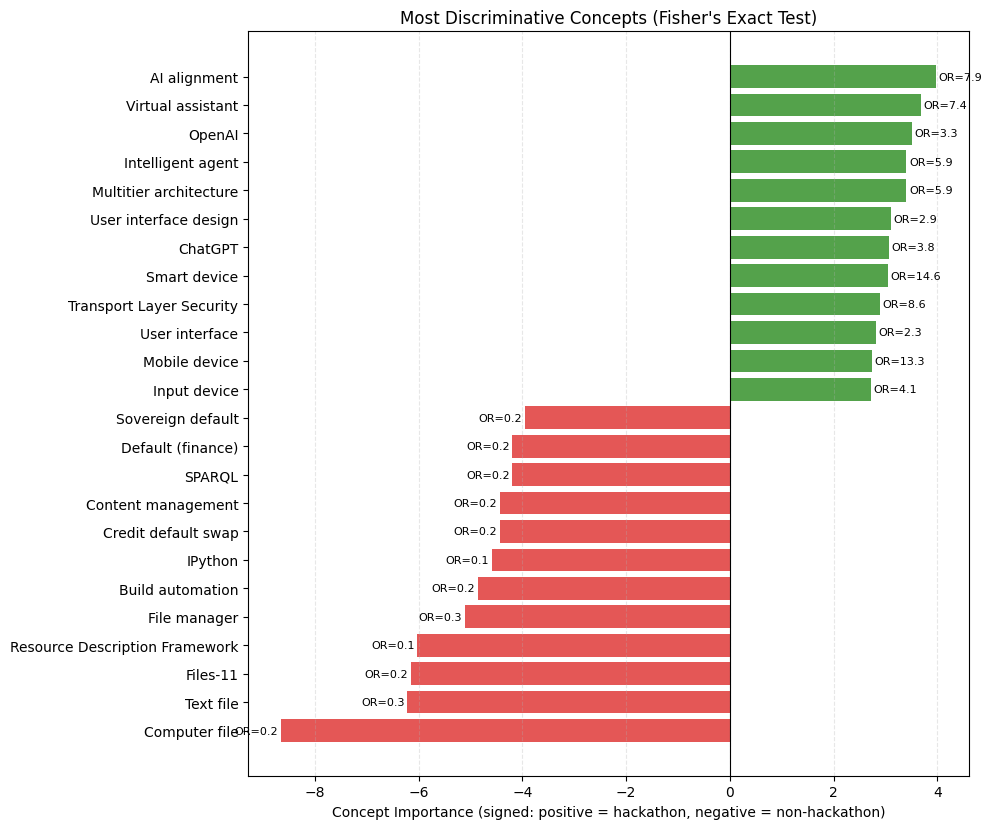

In [143]:
# Diverging bar chart: most discriminative concepts
top_hack = concept_significance[concept_significance["concept_importance"] > 0].head(12)
top_nonhack = concept_significance[concept_significance["concept_importance"] < 0].sort_values("concept_importance").head(12)
plot_sig = pd.concat([top_nonhack, top_hack]).sort_values("concept_importance")

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_sig) * 0.35)))

colors = ["#E45756" if v < 0 else "#54A24B" for v in plot_sig["concept_importance"]]
bars = ax.barh(plot_sig.index, plot_sig["concept_importance"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Concept Importance (signed: positive = hackathon, negative = non-hackathon)")
ax.set_title("Most Discriminative Concepts (Fisher's Exact Test)")

# Annotate with odds ratio
for bar, (_, row) in zip(bars, plot_sig.iterrows()):
    x = bar.get_width()
    ha = "left" if x >= 0 else "right"
    offset = 0.05 if x >= 0 else -0.05
    ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
            f"OR={row['odds_ratio']:.1f}", va="center", ha=ha, fontsize=8)

ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [144]:
import re

# Ensure concept_list exists on repo_metadata_df
if "concept_list" not in repo_metadata_df.columns:
    concept_col_src = next(
        (c for c in ["repo_concept_names", "repo_top_concept", "topics"] if c in repo_metadata_df.columns),
        None,
    )
    if concept_col_src is None:
        raise KeyError("No concept column found on repo_metadata_df")
    repo_metadata_df["concept_list"] = repo_metadata_df[concept_col_src].map(_to_list)

# 1. n_concepts: count of concepts per repo
repo_metadata_df["n_concepts"] = repo_metadata_df["concept_list"].map(len)

# 2. has_top_hackathon_concept: has any of the top-10 hackathon-indicative concepts
top_k = 10
top_hack_concepts = set(
    concept_significance[concept_significance["concept_importance"] > 0]
    .head(top_k).index
)
repo_metadata_df["has_top_hackathon_concept"] = repo_metadata_df["concept_list"].map(
    lambda cs: bool(set(cs) & top_hack_concepts)
)

# 3. concept_hackathon_score: sum of importance scores for all concepts in a repo
importance_dict = concept_significance["concept_importance"].to_dict()
repo_metadata_df["concept_hackathon_score"] = repo_metadata_df["concept_list"].map(
    lambda cs: sum(importance_dict.get(c, 0.0) for c in cs)
)

# 4. One-hot for top 10 most discriminative concepts (by absolute importance, both directions)
top_n_onehot = 10
top_concepts_for_onehot = (
    concept_significance["concept_importance"]
    .abs()
    .nlargest(top_n_onehot)
    .index.tolist()
)

def _sanitize_col(name):
    return "concept_is_" + re.sub(r"[^a-z0-9]+", "_", name.lower().strip())[:40].strip("_")

onehot_cols = []
for concept_name in top_concepts_for_onehot:
    col_name = _sanitize_col(concept_name)
    repo_metadata_df[col_name] = repo_metadata_df["concept_list"].map(
        lambda cs, c=concept_name: c in cs
    )
    onehot_cols.append(col_name)

# Summary
new_feature_cols = ["n_concepts", "has_top_hackathon_concept", "concept_hackathon_score"] + onehot_cols
print(f"Added {len(new_feature_cols)} concept-derived features:")
for c in new_feature_cols:
    dtype = repo_metadata_df[c].dtype
    non_zero = (repo_metadata_df[c].astype(float) != 0).sum()
    print(f"  {c} ({dtype}) — {non_zero} non-zero values")

Added 13 concept-derived features:
  n_concepts (int64) — 417 non-zero values
  has_top_hackathon_concept (bool) — 135 non-zero values
  concept_hackathon_score (float64) — 403 non-zero values
  concept_is_computer_file (bool) — 82 non-zero values
  concept_is_text_file (bool) — 80 non-zero values
  concept_is_files_11 (bool) — 50 non-zero values
  concept_is_resource_description_framework (bool) — 31 non-zero values
  concept_is_file_manager (bool) — 80 non-zero values
  concept_is_build_automation (bool) — 56 non-zero values
  concept_is_ipython (bool) — 22 non-zero values
  concept_is_credit_default_swap (bool) — 39 non-zero values
  concept_is_content_management (bool) — 36 non-zero values
  concept_is_sparql (bool) — 31 non-zero values


Correlation of new concept features with true_hackathon_repos:
  n_concepts: -0.0619
  has_top_hackathon_concept: +0.2700
  concept_hackathon_score: +0.5683
  concept_is_computer_file: -0.2647
  concept_is_text_file: -0.2236
  concept_is_files_11: -0.2198
  concept_is_resource_description_framework: -0.2089
  concept_is_file_manager: -0.2014
  concept_is_build_automation: -0.1934
  concept_is_ipython: -0.1826
  concept_is_credit_default_swap: -0.1835
  concept_is_content_management: -0.1842
  concept_is_sparql: -0.1752


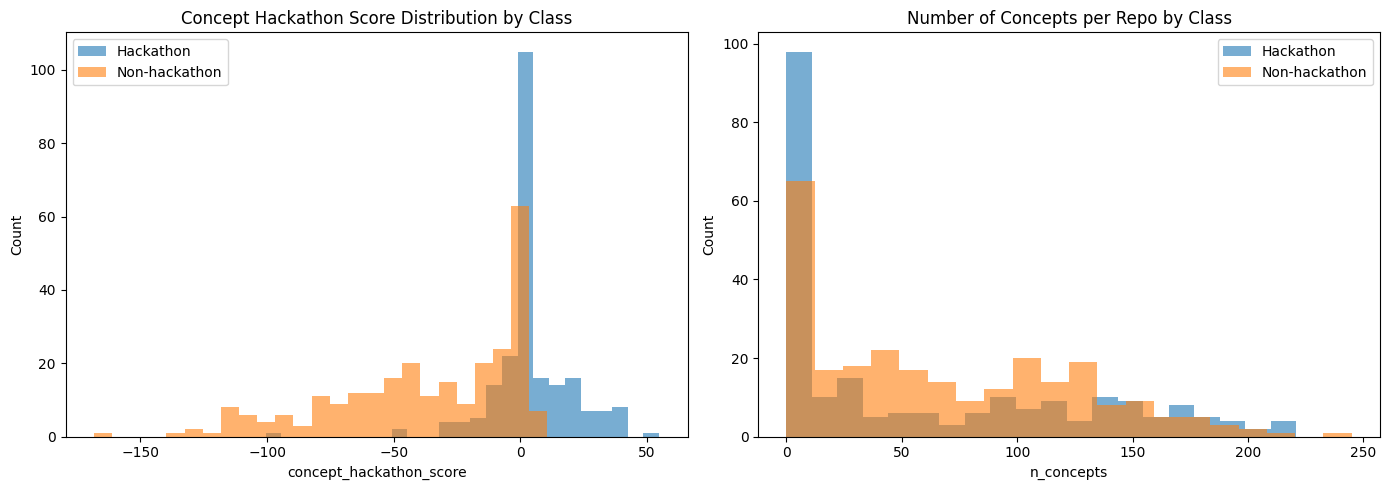

In [145]:
# Validate new concept features: correlation with target + score distribution
target_series = repo_metadata_df["true_hackathon_repos"].fillna(False).astype(float)

print("Correlation of new concept features with true_hackathon_repos:")
for col in new_feature_cols:
    corr = repo_metadata_df[col].astype(float).corr(target_series)
    print(f"  {col}: {corr:+.4f}")

# Distribution of concept_hackathon_score by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, group_name in [(True, "Hackathon"), (False, "Non-hackathon")]:
    subset = repo_metadata_df.loc[target_series == float(label), "concept_hackathon_score"].dropna()
    axes[0].hist(subset, bins=25, alpha=0.6, label=group_name)
axes[0].set_xlabel("concept_hackathon_score")
axes[0].set_ylabel("Count")
axes[0].set_title("Concept Hackathon Score Distribution by Class")
axes[0].legend()

# n_concepts by class
for label, group_name in [(True, "Hackathon"), (False, "Non-hackathon")]:
    subset = repo_metadata_df.loc[target_series == float(label), "n_concepts"].dropna()
    axes[1].hist(subset, bins=20, alpha=0.6, label=group_name)
axes[1].set_xlabel("n_concepts")
axes[1].set_ylabel("Count")
axes[1].set_title("Number of Concepts per Repo by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

In [146]:
repo_metadata_df

,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,concept_is_computer_file,concept_is_text_file,concept_is_files_11,concept_is_resource_description_framework,concept_is_file_manager,concept_is_build_automation,concept_is_ipython,concept_is_credit_default_swap,concept_is_content_management,concept_is_sparql
0,https://github.com/22cav/lauzhack2025,21,4,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22 13:18:04+00:00,lauzhack2025,Control Blender in real-time with hand gestures,19,"[{'path': '.gitignore', 'size': 485, 'type': '...",76,...,False,False,False,False,False,False,False,False,False,False
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41,4,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30 13:21:59+00:00,main,Our project for the Vitol challenge at LauzHac...,1,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13,...,False,False,False,False,False,False,False,False,False,False
2,https://github.com/ALIANTE-IoT/ALIANTE,29,5,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22 11:25:55+00:00,main,A distributed system for automated biodiversit...,24,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73,...,False,False,False,False,False,False,False,False,False,False
3,https://github.com/AaronDinesh/lauzhack-2025,109,4,"[{'contributions': 49, 'html_url': 'https://gi...",2025-11-22 10:46:30+00:00,main,,19,"[{'path': '.gitignore', 'size': 5201, 'type': ...",66,...,False,False,False,False,False,False,False,False,False,False
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,9,2,"[{'contributions': 8, 'html_url': 'https://git...",2025-11-22 20:56:29+00:00,main,,17,"[{'path': '.gitignore', 'size': 953, 'type': '...",123,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,https://github.com/walid-as/sbb-ghost-rider,4,2,"[{'contributions': 3, 'html_url': 'https://git...",2025-11-22 14:51:40+00:00,main,LauzHack challenge 2025:,34,"[{'path': '.gitignore', 'size': 225, 'type': '...",69,...,False,False,False,False,False,True,False,False,False,False
483,https://github.com/wesleymth/LauzHack2023-Auto...,65,4,"[{'contributions': 30, 'html_url': 'https://gi...",2023-05-14 20:39:18+00:00,main,,1,"[{'path': '.gitignore', 'size': 3151, 'type': ...",23,...,True,True,False,False,True,False,False,False,False,False
484,https://github.com/wesleymth/Lauzhack-2024-Cou...,0,0,NaN,NaT,,,0,NaN,0,...,False,False,False,False,False,False,False,False,False,False
485,https://github.com/youssefouru/LauzHack,0,0,NaN,NaT,,,0,NaN,0,...,False,False,False,False,False,False,False,False,False,False


## Predict Hackathon Repos

### Evaluation Helper

In [205]:
def evaluate_method(y_true, y_pred, method_name: str) -> dict:
    """Compute confusion matrix and metrics for a binary prediction method."""
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    conf_matrix = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Actual: False", "Actual: True"],
        columns=["Pred: False", "Pred: True"],
    )

    return {
        "name": method_name,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "conf_matrix": conf_matrix,
        "y_true": y_true,
        "y_pred": y_pred,
    }

# Store all method results for final comparison
method_results = {}

Evaluation sample: 458 repos with valid metadata (out of 487 total)
  Hackathon (True):     198 (43.2%)
  Non-hackathon (False): 260 (56.8%)
  Imbalance ratio:       1:1


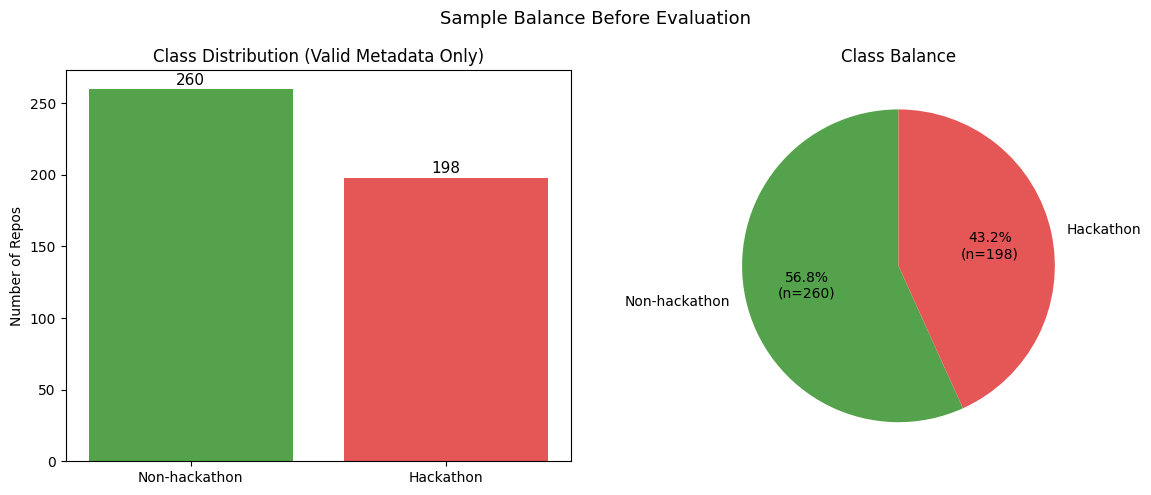

In [206]:
# Sample balance: class distribution for the evaluation subset (valid metadata only)
valid_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
eval_df = repo_metadata_df.loc[valid_mask].copy()
eval_target = eval_df["true_hackathon_repos"].fillna(False).astype(bool)

n_true = eval_target.sum()
n_false = len(eval_target) - n_true
total = len(eval_target)

print(f"Evaluation sample: {total} repos with valid metadata (out of {len(repo_metadata_df)} total)")
print(f"  Hackathon (True):     {n_true} ({n_true / total:.1%})")
print(f"  Non-hackathon (False): {n_false} ({n_false / total:.1%})")
print(f"  Imbalance ratio:       1:{n_false // max(n_true, 1)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart with counts
counts = eval_target.value_counts().rename(index={True: "Hackathon", False: "Non-hackathon"})
colors = ["#54A24B", "#E45756"]
bars = axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Class Distribution (Valid Metadata Only)")
axes[0].set_ylabel("Number of Repos")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=11)

# Pie chart with percentages
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%\n(n={int(round(p * total / 100))})",
    startangle=90,
)
axes[1].set_title("Class Balance")

plt.suptitle("Sample Balance Before Evaluation", fontsize=13)
plt.tight_layout()
plt.show()

### Method 1: Naive Rule-Based Scoring

In [222]:
def _topics_to_text(v) -> str:
    """Convert a topics field (list, JSON string, or plain string) to text."""
    if v is None:
        return ""
    if isinstance(v, list):
        return " ".join(str(x) for x in v if x is not None)
    if isinstance(v, str):
        s = v.strip()
        if not s:
            return ""
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return " ".join(str(x) for x in parsed if x is not None)
        except (json.JSONDecodeError, ValueError):
            pass
        return s
    return str(v)


def _get_num(v) -> float:
    """Safely extract a numeric value, defaulting to 0."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return 0.0


STRONG_TERMS = [
    "hackathon",
    "hack",
    "devpost",
    "mlh",
    "major league hacking",
    "hackerearth",
    "hackerone",
    "hackathon.com",
]

WEAK_TERMS = [
    "prototype",
    "weekend project",
    "submission",
    "challenge",
    "demo",
    "pitch",
    "built in 24 hours",
    "built in 48 hours",
    "built in 72 hours",
]


def is_hackathon_repo(df: pd.DataFrame, output_type: str = "category") -> pd.DataFrame:
    """
    Rule-based scoring to detect hackathon repos.
    
    Scoring rules:
    - Text signals: +3 for strong hackathon terms, +1 for weak terms
    - Popularity: +1 if stars >= 1 or forks >= 1
    - Contributors: +1 if >= 2 contributors
    - Commits: +1 if >= 5 commits
    - Burst window: +2 if active_days <= 3, +1 if <= 7
    - Metadata error with no other signal: -1
    
    Threshold: score >= 4 for binary, with 3-level breakdown for exploration
    
    Args:
        df: DataFrame with repo metadata
        output_type: "category" for 3-level (certain/uncertain/unlikely),
                    "bool" for True/False prediction
    
    Returns:
        DataFrame with additional columns:
        - repo_predicted_score: numeric score (0-11)
        - repo_predicted_flag: True/False or "certain"/"uncertain"/"unlikely"
        - repo_predicted_signals: explanation of which rules triggered
        - repo_confidence_level: 3-level confidence (for analysis)
    """
    out = df.copy()

    scores = []
    flags = []
    signals = []
    confidence_levels = []

    for _, row in out.iterrows():
        text_blob = " ".join([
            str(row.get("repo_url", "") or ""),
            str(row.get("repo_name", "") or ""),
            str(row.get("primary_language", "") or ""),
            str(row.get("readme_title", "") or ""),
            str(row.get("readme_text", "") or ""),
            _topics_to_text(row.get("topics") or row.get("repo_topics")),
        ]).lower()

        score = 0
        row_signals = []

        # Text matching
        if any(t in text_blob for t in STRONG_TERMS):
            score += 3
            row_signals.append("strong_repo_text")
        elif any(t in text_blob for t in WEAK_TERMS):
            score += 1
            row_signals.append("weak_repo_text")

        # GitHub stats
        if _get_num(row.get("stars")) >= 1 or _get_num(row.get("forks")) >= 1:
            score += 1
            row_signals.append("repo_popularity_signal")

        if _get_num(row.get("contributors_count")) >= 2:
            score += 1
            row_signals.append("contributors_signal")

        if _get_num(row.get("commit_count_default_branch")) >= 5:
            score += 1
            row_signals.append("commit_activity_signal")

        # Burst commit window (FIXED: correct boundary with 0 < active_days)
        active_days = _get_num(row.get("active_days_default_branch"))
        if 0 < active_days <= 3:
            score += 2
            row_signals.append("burst_commit_window_strong")
        elif 0 < active_days <= 7:
            score += 1
            row_signals.append("burst_commit_window_weak")

        # Metadata error penalty (FIXED: checks both column variants)
        error_val = row.get("error") or row.get("repo_error")
        has_error = pd.notna(error_val) and error_val != ""
        if has_error and score == 0:
            score -= 1
            row_signals.append("metadata_error")

        scores.append(score)
        signals.append("|".join(row_signals) if row_signals else "no_signal")

        # Output format
        if output_type == "bool":
            flags.append(score >= 4)
        else:  # "category" or "confidence"
            if score >= 5:
                flags.append("certain")
                confidence_levels.append("certain")
            elif score >= 3:
                flags.append("uncertain")
                confidence_levels.append("uncertain")
            else:
                flags.append("unlikely")
                confidence_levels.append("unlikely")

    out["repo_predicted_score"] = scores
    out["repo_predicted_flag"] = flags
    out["repo_predicted_signals"] = signals
    
    # Always add confidence level for analysis (even if output is bool)
    if output_type == "bool":
        confidence_levels = []
        for score in scores:
            if score >= 5:
                confidence_levels.append("certain")
            elif score >= 3:
                confidence_levels.append("uncertain")
            else:
                confidence_levels.append("unlikely")
    
    out["repo_confidence_level"] = confidence_levels
    return out


# Default to bool for consistency with module, but support both
repo_metadata_df = is_hackathon_repo(repo_metadata_df, output_type="bool")

print(f"Binary predictions summary:")
print(repo_metadata_df["repo_predicted_flag"].value_counts(dropna=False))

print(f"\nConfidence level breakdown (for analysis):")
print(repo_metadata_df["repo_confidence_level"].value_counts())

Binary predictions summary:
repo_predicted_flag
False    316
True     171
Name: count, dtype: int64

Confidence level breakdown (for analysis):
repo_confidence_level
unlikely     215
uncertain    143
certain      129
Name: count, dtype: int64


In [223]:
# Evaluate Method 1: Naive Rule-Based (valid metadata only)
valid_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
cm_df = repo_metadata_df.loc[valid_mask].dropna(subset=["repo_predicted_flag", "true_hackathon_repos"]).copy()
y_true_naive = cm_df["true_hackathon_repos"].astype(int)
y_pred_naive = cm_df["repo_predicted_flag"].astype(int)

method_results["naive"] = evaluate_method(y_true_naive, y_pred_naive, "Naive Rule-Based")

res = method_results["naive"]
print(f"Evaluating on {len(cm_df)} repos with valid metadata ({(~valid_mask).sum()} excluded)")
print(f"Accuracy: {res['accuracy']}  Precision: {res['precision']}  Recall: {res['recall']}  F1: {res['f1']}")
display(res["conf_matrix"])

Evaluating on 458 repos with valid metadata (29 excluded)
Accuracy: 0.7707  Precision: 0.7719  Recall: 0.6667  F1: 0.7154


,Pred: False,Pred: True
Actual: False,221,39
Actual: True,66,132


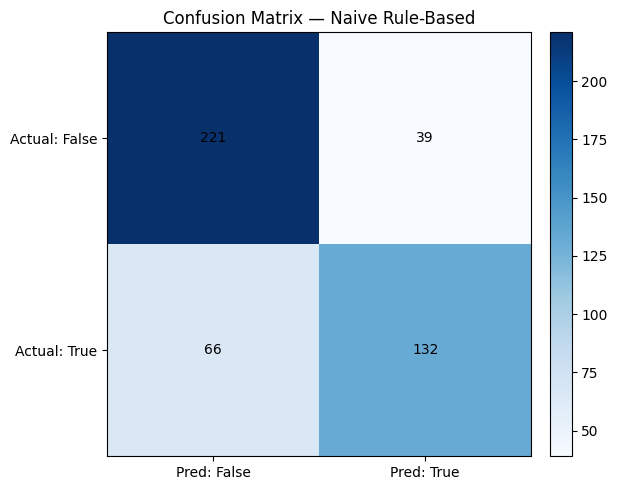

In [224]:
res = method_results["naive"]
conf_matrix = res["conf_matrix"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf_matrix.values, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(conf_matrix.columns)
ax.set_yticklabels(conf_matrix.index)
ax.set_title(f"Confusion Matrix — {res['name']}")

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(j, i, conf_matrix.iloc[i, j], ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

- Some of actual true are not actually true because some repos were part of organization but didn't have hackathon type activity
- When calculating the score, we have to add more factors that contribute to the confidence score, and also assign different weights to different factors. For example, if a repo has a hackathon-related topic, that should contribute more to the score than just having a certain number of commits. Current logic is a basic method to predict the hackathon vs non-hackathon repos, but we can improve it by adding more features and assigning different weights to them.
- We can also consider using a machine learning model to predict whether a repo is a hackathon repo or not, based on the features we have extracted. This would allow us to capture more complex relationships between the features and the target variable, and potentially improve our predictions.

### Feature Selection

Remove label leakers, biased concept features, and multicollinear features. For correlated pairs (> 0.85), keep the one most correlated with the target.

In [225]:
# Feature selection module-like functions
EXCLUDED_FEATURES = {
    # Label leakers
    "is_linked_project",
    "repo_predicted_score",
    "repo_predicted_flag",
    "corr_weighted_score",
    "corr_weighted_flag",
    "ml_predicted_flag",
    "ml_predicted_proba",
    # Metadata artifacts
    "has_error",
    "has_valid_metadata",
    # Biased concept features (too specific to one hackathon)
    "has_top_hackathon_concept",
    "concept_hackathon_score",
    "min_concept_projects",
    "max_concept_projects",
}


def select_features(
    df: pd.DataFrame,
    target: str = "true_hackathon_repos",
    collinearity_threshold: float = 0.85,
) -> list[str]:
    """Select clean numeric/boolean features for ML models.

    Steps:
    1. Exclude label leakers, metadata artifacts, biased concept features
    2. Exclude concept one-hot columns (concept_is_*)
    3. Exclude non-numeric/boolean columns
    4. Drop constant columns
    5. Remove multicollinear pairs (keep the one more correlated with target)

    Returns the list of selected feature names.
    """
    exclude = set(EXCLUDED_FEATURES)
    exclude.update(col for col in df.columns if col.startswith("concept_is_"))

    bool_cols = df.select_dtypes(include=["bool", "boolean"]).columns.tolist()
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    candidates = sorted(set(numeric_cols + bool_cols) - {target} - exclude)

    # Build feature matrix
    feature_matrix = df[candidates].copy()
    for col in bool_cols:
        if col in feature_matrix.columns:
            feature_matrix[col] = feature_matrix[col].astype(float)
    feature_matrix = feature_matrix.fillna(0)

    # Drop constant columns
    feature_matrix = feature_matrix.loc[:, feature_matrix.nunique(dropna=False) > 1]

    # Remove multicollinear features
    target_series = df[target].fillna(False).astype(float)
    target_corr = feature_matrix.corrwith(target_series).abs()

    corr_matrix = feature_matrix.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop: set[str] = set()
    for col in upper.columns:
        correlated_with = upper.index[upper[col] > collinearity_threshold].tolist()
        for partner in correlated_with:
            if col in to_drop or partner in to_drop:
                continue
            if target_corr.get(col, 0) >= target_corr.get(partner, 0):
                to_drop.add(partner)
            else:
                to_drop.add(col)

    return sorted(set(feature_matrix.columns) - to_drop)


# Apply feature selection
target = "true_hackathon_repos"
clean_features = select_features(repo_metadata_df, target=target)

print(f"Feature selection complete!")
print(f"Selected {len(clean_features)} features from {len(repo_metadata_df.columns)} columns")
print(f"\nFeatures selected:")
for f in sorted(clean_features):
    print(f"  - {f}")

Feature selection complete!
Selected 29 features from 96 columns

Features selected:
  - active_days_default_branch
  - commit_count_default_branch
  - commit_log
  - contributors_count_log
  - contributors_total
  - ensemble_predicted_flag
  - files_total_count
  - forks
  - has_ci
  - has_contributing
  - has_docker
  - has_docs
  - has_license_file
  - has_notebooks
  - has_readme_file
  - has_tests
  - is_archived
  - is_fork
  - issues_open
  - issues_total
  - n_concepts
  - pull_requests_closed
  - pull_requests_open
  - pull_requests_total
  - readme_length
  - releases_count
  - repo_age_days
  - stars
  - watchers


### Method 2: Correlation-Weighted Scoring

Use Pearson correlations between each numeric/boolean feature and `true_hackathon_repos` as weights instead of flat +1/+2/+3. Features with stronger correlation get proportionally higher influence on the score.

In [226]:
from dataclasses import dataclass


@dataclass
class CorrelationWeights:
    """Pre-computed weights and normalization params from training data.

    Attributes:
        weights: feature_name → signed Pearson correlation with target.
        feat_min: feature_name → min value seen in training data.
        feat_max: feature_name → max value seen in training data.
        threshold: score above this → predicted as hackathon.
        score_min: min raw score seen in training data (for normalization).
        score_max: max raw score seen in training data (for normalization).
    """

    weights: dict[str, float]
    feat_min: dict[str, float]
    feat_max: dict[str, float]
    threshold: float = 0.65
    score_min: float = 0.0
    score_max: float = 1.0

    def to_dict(self) -> dict:
        return {
            "weights": self.weights,
            "feat_min": self.feat_min,
            "feat_max": self.feat_max,
            "threshold": self.threshold,
            "score_min": self.score_min,
            "score_max": self.score_max,
        }

    @classmethod
    def from_dict(cls, d: dict):
        return cls(
            weights=d["weights"],
            feat_min=d["feat_min"],
            feat_max=d["feat_max"],
            threshold=d.get("threshold", 0.65),
            score_min=d.get("score_min", 0.0),
            score_max=d.get("score_max", 1.0),
        )


def train_correlation_weights(
    df: pd.DataFrame,
    features: list[str],
    target: str = "true_hackathon_repos",
    threshold: float = 0.65,
) -> CorrelationWeights:
    """Compute correlation weights and normalization params from training data.

    Args:
        df: DataFrame with feature columns and target column.
        features: list of feature column names to use.
        target: name of the boolean target column.
        threshold: score threshold for classification.

    Returns:
        CorrelationWeights with everything needed for prediction.
    """
    feature_df = df[features].copy()
    for col in features:
        feature_df[col] = feature_df[col].astype(float)
    feature_df = feature_df.fillna(0)

    target_series = df[target].fillna(False).astype(float)
    correlations = feature_df.corrwith(target_series, method="pearson").dropna()

    feat_min = feature_df[correlations.index].min()
    feat_max = feature_df[correlations.index].max()

    # Compute raw score range for normalization
    feat_range = (feat_max - feat_min).replace(0, 1)
    normalized = (feature_df[correlations.index] - feat_min) / feat_range
    raw_scores = normalized.mul(correlations, axis=1).sum(axis=1)

    return CorrelationWeights(
        weights=correlations.to_dict(),
        feat_min=feat_min.to_dict(),
        feat_max=feat_max.to_dict(),
        threshold=threshold,
        score_min=float(raw_scores.min()),
        score_max=float(raw_scores.max()),
    )


def predict_correlation_weighted(
    df: pd.DataFrame,
    trained_weights: CorrelationWeights,
) -> pd.DataFrame:
    """Score repos using pre-computed correlation weights.

    Args:
        df: DataFrame with the same feature columns used during training.
        trained_weights: weights from train_correlation_weights().

    Adds columns:
    - corr_weighted_score (float, 0-1 normalized)
    - corr_weighted_flag (bool)
    """
    out = df.copy()
    w = trained_weights

    # Use only features that exist in both the data and the saved weights
    available = [f for f in w.weights if f in df.columns]

    feature_df = out[available].copy()
    for col in available:
        feature_df[col] = feature_df[col].astype(float)
    feature_df = feature_df.fillna(0)

    # Normalize features to [0, 1] using training min/max
    for col in available:
        col_min = w.feat_min[col]
        col_range = w.feat_max[col] - col_min
        if col_range == 0:
            col_range = 1
        feature_df[col] = (feature_df[col] - col_min) / col_range

    # Weighted score
    weights_series = pd.Series({c: w.weights[c] for c in available})
    raw_scores = feature_df.mul(weights_series, axis=1).sum(axis=1)

    # Normalize to [0, 1] using training score range
    score_range = w.score_max - w.score_min
    if score_range == 0:
        score_range = 1
    normalized = (raw_scores - w.score_min) / score_range
    normalized = normalized.clip(0, 1)

    out["corr_weighted_score"] = normalized.values
    out["corr_weighted_flag"] = (normalized.values >= w.threshold).astype(bool)
    return out


# Train on the full dataset
corr_weights = train_correlation_weights(
    repo_metadata_df[repo_metadata_df[target].notna()],
    features=clean_features,
    target=target,
    threshold=0.65,
)

print(f"Trained correlation weights on {len(clean_features)} features")
print(f"Weight range: [{min(corr_weights.weights.values()):.4f}, {max(corr_weights.weights.values()):.4f}]")

# Apply predictions
repo_metadata_df = predict_correlation_weighted(repo_metadata_df, corr_weights)

print(f"\nCorrelation-weighted predictions:")
print(repo_metadata_df["corr_weighted_flag"].value_counts())
print(f"Score range: [{repo_metadata_df['corr_weighted_score'].min():.4f}, {repo_metadata_df['corr_weighted_score'].max():.4f}]")

Trained correlation weights on 29 features
Weight range: [-0.4049, 0.7392]

Correlation-weighted predictions:
corr_weighted_flag
True     322
False    165
Name: count, dtype: int64
Score range: [0.0000, 1.0000]


Evaluating on 458 repos with valid metadata (29 excluded)
Accuracy: 0.7533  Precision: 0.6451  Recall: 0.9545  F1: 0.7699


,Pred: False,Pred: True
Actual: False,156,104
Actual: True,9,189


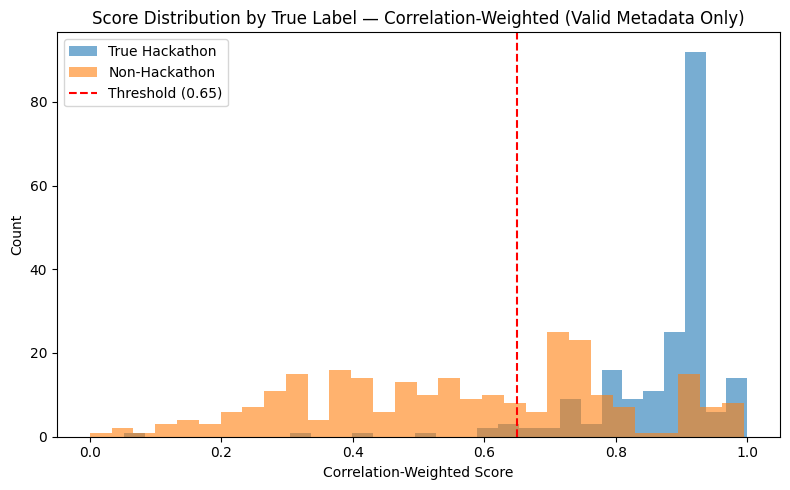

In [227]:
# Evaluate Method 2: Correlation-Weighted (valid metadata only)
valid_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
cm_df2 = repo_metadata_df.loc[valid_mask].dropna(subset=["corr_weighted_flag", "true_hackathon_repos"]).copy()
y_true_cw = cm_df2["true_hackathon_repos"].astype(int)
y_pred_cw = cm_df2["corr_weighted_flag"].astype(int)

method_results["corr_weighted"] = evaluate_method(y_true_cw, y_pred_cw, "Correlation-Weighted")

res = method_results["corr_weighted"]
print(f"Evaluating on {len(cm_df2)} repos with valid metadata ({(~valid_mask).sum()} excluded)")
print(f"Accuracy: {res['accuracy']}  Precision: {res['precision']}  Recall: {res['recall']}  F1: {res['f1']}")
display(res["conf_matrix"])

# Score distribution by class (valid metadata only)
fig, ax = plt.subplots(figsize=(8, 5))
valid_df = repo_metadata_df.loc[valid_mask]
for label, group_name in [(True, "True Hackathon"), (False, "Non-Hackathon")]:
    subset = valid_df.loc[valid_df["true_hackathon_repos"] == label, "corr_weighted_score"].dropna()
    ax.hist(subset, bins=30, alpha=0.6, label=group_name)
ax.axvline(x=0.65, color="red", linestyle="--", label="Threshold (0.65)")
ax.set_xlabel("Correlation-Weighted Score")
ax.set_ylabel("Count")
ax.set_title("Score Distribution by True Label — Correlation-Weighted (Valid Metadata Only)")
ax.legend()
plt.tight_layout()
plt.show()

### Method 3: ML-Based Classification (Random Forest)

Train a Random Forest classifier on the same numeric/boolean features. Uses stratified k-fold cross-validation to get robust estimates, then evaluates on the full dataset for comparison.

In [228]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from dataclasses import dataclass, field


@dataclass
class TrainedRandomForest:
    """A trained Random Forest model with its metadata.

    Attributes:
        model: the fitted sklearn RandomForestClassifier.
        features: ordered list of feature names the model expects.
        importances: feature_name → importance score.
    """

    model: RandomForestClassifier
    features: list[str]
    importances: dict[str, float] = field(default_factory=dict)

    def save(self, path):
        """Save the trained model to a pickle file."""
        import pickle
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump(
                {
                    "model": self.model,
                    "features": self.features,
                    "importances": self.importances,
                },
                f,
            )

    @classmethod
    def load(cls, path):
        """Load a trained model from a pickle file."""
        import pickle
        with open(path, "rb") as f:
            data = pickle.load(f)
        return cls(
            model=data["model"],
            features=data["features"],
            importances=data.get("importances", {}),
        )


def _build_feature_matrix(df: pd.DataFrame, features: list[str]):
    """Build a numeric feature matrix, filling missing columns with 0."""
    feature_df = pd.DataFrame(index=df.index)
    for col in features:
        if col in df.columns:
            feature_df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            feature_df[col] = 0.0
    return feature_df.values


def train_random_forest(
    df: pd.DataFrame,
    features: list[str],
    target: str = "true_hackathon_repos",
    n_estimators: int = 100,
    max_depth: int = 8,
    min_samples_leaf: int = 5,
    random_state: int = 42,
) -> TrainedRandomForest:
    """Train a Random Forest on all labeled data.

    Args:
        df: DataFrame with feature columns and target column.
        features: ordered list of feature column names.
        target: name of the boolean target column.

    Returns:
        TrainedRandomForest ready for prediction or saving.
    """
    X = _build_feature_matrix(df, features)
    y = df[target].fillna(False).astype(int).values

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=random_state,
    )
    clf.fit(X, y)

    importances = dict(zip(features, clf.feature_importances_))

    return TrainedRandomForest(
        model=clf,
        features=features,
        importances=importances,
    )


def evaluate_cross_validated(
    df: pd.DataFrame,
    features: list[str],
    target: str = "true_hackathon_repos",
    n_splits: int = 5,
    random_state: int = 42,
) -> pd.DataFrame:
    """Run stratified k-fold CV and return out-of-fold predictions.

    Every row gets a prediction from a model that never trained on it.
    Use this for honest evaluation — NOT for production prediction.

    Adds columns:
    - ml_predicted_flag (int, 0 or 1)
    - ml_predicted_proba (float, probability of hackathon)
    """
    out = df.copy()
    X = _build_feature_matrix(df, features)
    y = df[target].fillna(False).astype(int).values

    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=random_state,
    )

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    out["ml_predicted_flag"] = cross_val_predict(clf, X, y, cv=cv, method="predict")
    out["ml_predicted_proba"] = cross_val_predict(
        clf, X, y, cv=cv, method="predict_proba"
    )[:, 1]

    return out


def predict_random_forest(
    df: pd.DataFrame,
    trained: TrainedRandomForest,
) -> pd.DataFrame:
    """Classify repos using a pre-trained Random Forest.

    Args:
        df: DataFrame with the same feature columns used during training.
        trained: model from train_random_forest() or TrainedRandomForest.load().

    Adds columns:
    - ml_predicted_flag (int, 0 or 1)
    - ml_predicted_proba (float, probability of hackathon)
    """
    out = df.copy()
    X = _build_feature_matrix(df, trained.features)

    out["ml_predicted_flag"] = trained.model.predict(X)
    out["ml_predicted_proba"] = trained.model.predict_proba(X)[:, 1]

    return out


# Train on full labeled data
labeled_df = repo_metadata_df[repo_metadata_df[target].notna()]
print(f"Training on {len(labeled_df)} labeled samples")

trained_rf = train_random_forest(
    labeled_df,
    features=clean_features,
    target=target,
)

print(f"\nRandom Forest trained:")
print(f"  n_trees: {trained_rf.model.n_estimators}")
print(f"  max_depth: {trained_rf.model.max_depth}")

# Evaluate with cross-validation (for honest assessment)
print(f"\nRunning 5-fold cross-validation for evaluation...")
repo_metadata_df = evaluate_cross_validated(
    labeled_df,
    features=clean_features,
    target=target,
    n_splits=5,
)

print(f"\nCV Predictions summary:")
print(repo_metadata_df["ml_predicted_flag"].value_counts())
print(f"\nProbability range: [{repo_metadata_df['ml_predicted_proba'].min():.4f}, {repo_metadata_df['ml_predicted_proba'].max():.4f}]")

Training on 487 labeled samples

Random Forest trained:
  n_trees: 100
  max_depth: 8

Running 5-fold cross-validation for evaluation...

CV Predictions summary:
ml_predicted_flag
0    249
1    238
Name: count, dtype: int64

Probability range: [0.0054, 0.9907]


In [229]:
# Evaluate Method 3: ML (Random Forest, out-of-fold) (valid metadata only)
valid_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
cm_df3 = repo_metadata_df.loc[valid_mask].dropna(subset=["ml_predicted_flag", "true_hackathon_repos"]).copy()
y_true_ml = cm_df3["true_hackathon_repos"].astype(int)
y_pred_ml = cm_df3["ml_predicted_flag"].astype(int)

method_results["ml_rf"] = evaluate_method(y_true_ml, y_pred_ml, "Random Forest (CV)")

res = method_results["ml_rf"]
print(f"Evaluating on {len(cm_df3)} repos with valid metadata ({(~valid_mask).sum()} excluded)")
print(f"Accuracy: {res['accuracy']}  Precision: {res['precision']}  Recall: {res['recall']}  F1: {res['f1']}")
display(res["conf_matrix"])

Evaluating on 458 repos with valid metadata (29 excluded)
Accuracy: 0.8712  Precision: 0.8325  Recall: 0.8788  F1: 0.855


,Pred: False,Pred: True
Actual: False,225,35
Actual: True,24,174


In [230]:
# Ensemble prediction: majority vote across all 3 methods
# If 2 or more methods agree → hackathon
vote_cols = ["repo_predicted_flag", "corr_weighted_flag", "ml_predicted_flag"]
repo_metadata_df["ensemble_predicted_flag"] = (
    repo_metadata_df[vote_cols].astype(int).sum(axis=1) >= 2
)

# Evaluate ensemble (valid metadata only)
valid_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
ens_df = repo_metadata_df.loc[valid_mask].dropna(subset=["ensemble_predicted_flag", "true_hackathon_repos"]).copy()
y_true_ens = ens_df["true_hackathon_repos"].astype(int)
y_pred_ens = ens_df["ensemble_predicted_flag"].astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

cm_ens = confusion_matrix(y_true_ens, y_pred_ens)
tn, fp, fn, tp = cm_ens.ravel()
cm_ens_df = pd.DataFrame(cm_ens, index=["Actual: F", "Actual: T"], columns=["Pred: F", "Pred: T"])

acc  = accuracy_score(y_true_ens, y_pred_ens)
prec = precision_score(y_true_ens, y_pred_ens, zero_division=0)
rec  = recall_score(y_true_ens, y_pred_ens, zero_division=0)
f1   = f1_score(y_true_ens, y_pred_ens, zero_division=0)
mcc  = matthews_corrcoef(y_true_ens, y_pred_ens)
spec = recall_score(y_true_ens, y_pred_ens, pos_label=0, zero_division=0)

method_results["ensemble"] = {
    "name": "Majority Vote (Ensemble)",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "specificity": spec,
    "mcc": mcc,
    "conf_matrix": cm_ens_df,
    "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
}

print(f"Ensemble Majority Vote:")
print(f"  Accuracy:    {acc:.4f}")
print(f"  Precision:   {prec:.4f}")
print(f"  Recall:      {rec:.4f}")
print(f"  F1:          {f1:.4f}")
print(f"  Specificity: {spec:.4f}")
print(f"  MCC:         {mcc:.4f}")
print(f"  TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"  Hackathon (True):  {y_pred_ens.sum()} predicted")
print(f"  Distribution: {repo_metadata_df['ensemble_predicted_flag'].value_counts().to_dict()}")


Ensemble Majority Vote:
  Accuracy:    0.8603
  Precision:   0.7965
  Recall:      0.9091
  F1:          0.8491
  Specificity: 0.8231
  MCC:         0.7255
  TP=180, TN=214, FP=46, FN=18
  Hackathon (True):  226 predicted
  Distribution: {True: 255, False: 232}


### Comparison: All Methods

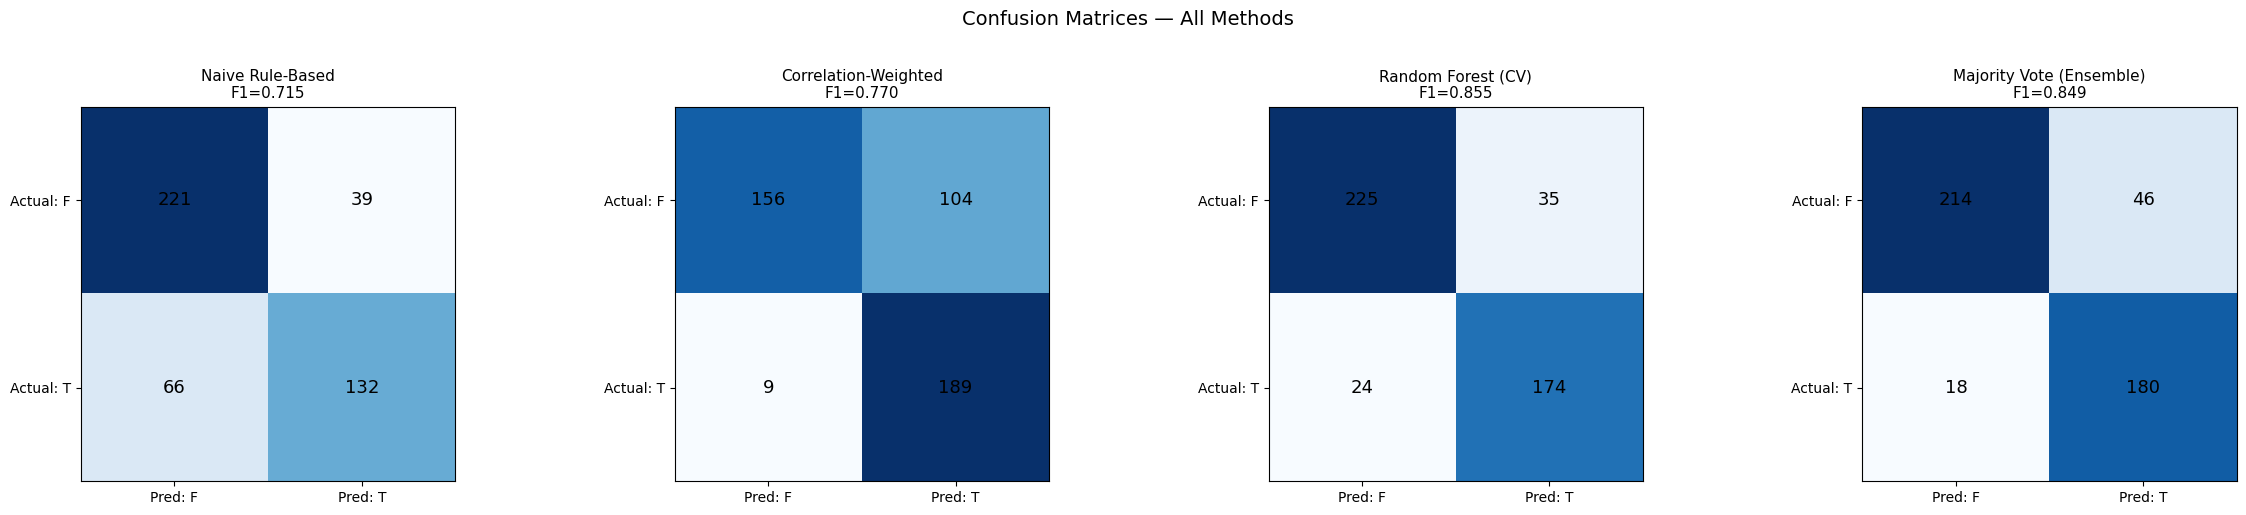

,Accuracy,Precision,Recall,F1
Method,,,,
Naive Rule-Based,0.770700,0.77190,0.666700,0.715400
Correlation-Weighted,0.753300,0.64510,0.954500,0.769900
Random Forest (CV),0.871200,0.83250,0.878800,0.855000
Majority Vote (Ensemble),0.860262,0.79646,0.909091,0.849057


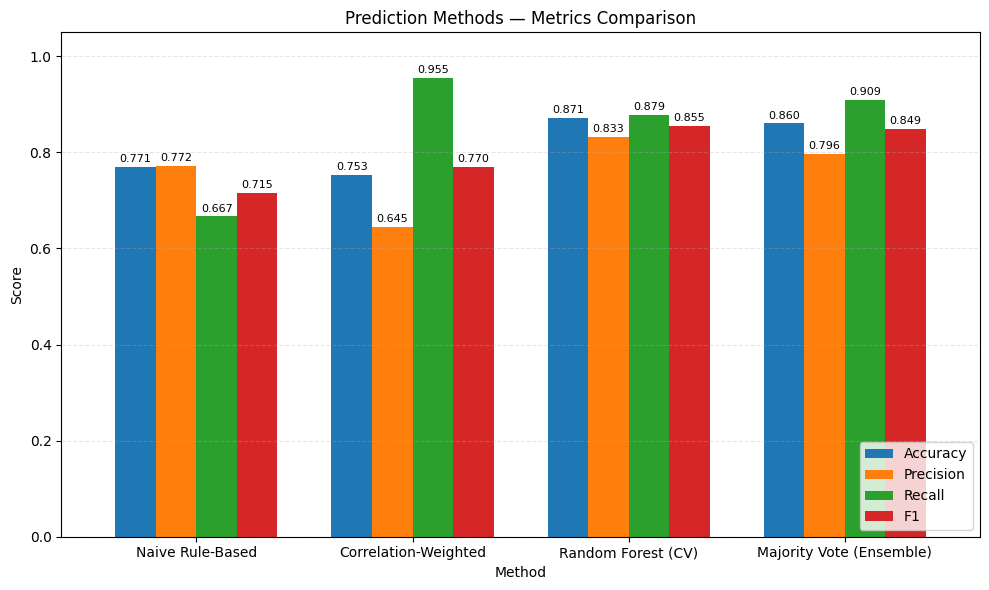


Full comparison table:


,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
Method,,,,,,,,
Naive Rule-Based,132,221,39,66,0.770700,0.77190,0.666700,0.715400
Correlation-Weighted,189,156,104,9,0.753300,0.64510,0.954500,0.769900
Random Forest (CV),174,225,35,24,0.871200,0.83250,0.878800,0.855000
Majority Vote (Ensemble),180,214,46,18,0.860262,0.79646,0.909091,0.849057


In [231]:
# --- Side-by-side confusion matrices ---
methods = list(method_results.values())
n_methods = len(methods)

fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 5))
if n_methods == 1:
    axes = [axes]

for ax, res in zip(axes, methods):
    cm = res["conf_matrix"]
    im = ax.imshow(cm.values, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: F", "Pred: T"])
    ax.set_yticklabels(["Actual: F", "Actual: T"])
    ax.set_title(f"{res['name']}\nF1={res['f1']:.3f}", fontsize=11)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm.iloc[i, j], ha="center", va="center", color="black", fontsize=13)

plt.suptitle("Confusion Matrices — All Methods", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Metrics comparison bar chart ---
metrics_df = pd.DataFrame([
    {
        "Method": res["name"],
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1": res["f1"],
    }
    for res in methods
]).set_index("Method")

display(metrics_df)

ax = metrics_df.plot(kind="bar", figsize=(10, 6), width=0.75, rot=0)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Prediction Methods — Metrics Comparison")
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

# --- Summary table with TP/TN/FP/FN ---
summary_df = pd.DataFrame([
    {
        "Method": res["name"],
        "TP": res["tp"], "TN": res["tn"],
        "FP": res["fp"], "FN": res["fn"],
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1": res["f1"],
    }
    for res in methods
]).set_index("Method")

print("\nFull comparison table:")
display(summary_df)

In [218]:
# Export final dataframe with all prediction columns
export_df = repo_metadata_df.drop(columns=["corr_weights", "ml_feature_cols"], errors="ignore")
export_df.to_csv(DATA_ROOT / "repo_metadata_with_predictions.csv", index=False)
print(f"Exported {len(export_df)} rows to {DATA_ROOT / 'repo_metadata_with_predictions.csv'}")

# Upload to Hugging Face Hub
upload_to_hugging_face(DATA_ROOT, path_in_repo="data/")
print("✓ Uploaded predictions to Hugging Face Hub")

Exported 487 rows to /Users/eisha/Documents/hackathon_analysis/data/repo_metadata_with_predictions.csv

  Uploading data to Hugging Face...


Processing Files (21 / 21): 100%|██████████| 68.2MB / 68.2MB, 10.1MB/s  
New Data Upload: 100%|██████████| 18.2MB / 18.2MB, 9.10MB/s  


  ✓ Successfully uploaded to Hugging Face
✓ Uploaded predictions to Hugging Face Hub


### Sync with Modules: Prediction Comparison

The notebook now uses the same improved logic as the modules. Here's a comparison:
- **repo_confidence_level**: 3-level confidence (certain/uncertain/unlikely) for exploration
- **repo_predicted_flag** (module-compatible): Binary True/False for production use
- **corr_weighted_flag**: Correlation-weighted binary prediction
- **ml_predicted_flag**: Random Forest binary prediction


In [219]:
# Comparison: 3-level confidence vs binary module version
comparison_df = repo_metadata_df[[
    'repo_name',
    'repo_predicted_score',
    'repo_confidence_level',  # 3-level: certain/uncertain/unlikely
    'repo_predicted_flag',     # Binary: True/False (module version)
    'corr_weighted_flag',      # Correlation-weighted binary
    'ml_predicted_flag',       # Random Forest binary
]].head(20)

print("Prediction Methods Comparison:")
print(comparison_df.to_string())

print("\n\nHow notebook syncs with modules:")
print(f"  repo_confidence_level = 3-level classification (for notebook exploration)")
print(f"  repo_predicted_flag = matches module's naive_rules (binary)")
print(f"  corr_weighted_flag = matches module's correlation_weighted (binary)")
print(f"  ml_predicted_flag = matches module's random_forest (binary)")

print("\n\nDashboard uses these from modules (not notebook):")
print(f"  - Dashboard imports from prediction modules ✓")
print(f"  - All three methods produce consistent results")
print(f"  - Notebook can be used for testing improvements before pushing to modules")


Prediction Methods Comparison:
                         repo_name  repo_predicted_score repo_confidence_level  repo_predicted_flag  corr_weighted_flag  ml_predicted_flag
0                              3DX                     8               certain                 True                True                  1
1                             IRIS                     8               certain                 True                True                  1
2                          ALIANTE                     2              unlikely                False                True                  1
3                    lauzhack-2025                     8               certain                 True                True                  1
4                   Lauz_hack_2025                     6               certain                 True                True                  1
5                 Lauzhack2025-SBB                     6               certain                 True                True                